# Hotel Bar Inventory Forecasting & Par Level Recommendation

**Prepared by:** Swamy Keerthi Naga Akshay

This notebook covers data preparation, exploratory analysis, demand forecasting, dynamic Par Level calculation, and inventory simulation for 96 Bar × Brand series.


**Step 1 — Data Cleaning**

Install/import libraries

In [77]:
# Core data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Forecasting
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# Machine learning
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

# Utilities
import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully.")

Libraries imported successfully.


### Set the dataset path


In [ ]:
from pathlib import Path

DATA_PATH = Path("data/raw/Consumption Dataset.xlsx")
if not DATA_PATH.exists():
    DATA_PATH = Path("../data/raw/Consumption Dataset.xlsx")

print(f"Dataset path: {DATA_PATH.resolve()}")


Load the dataset

In [ ]:
df = pd.read_excel(DATA_PATH)

print("Dataset loaded successfully.")
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

df.head()


Inspect the structure

In [37]:
print("Column names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

print("\nDataset shape:")
print(df.shape)

Column names:
['Date Time Served', 'Bar Name', 'Alcohol Type', 'Brand Name', 'Opening Balance (ml)', 'Purchase (ml)', 'Consumed (ml)', 'Closing Balance (ml)']

Data types:
Date Time Served        datetime64[ns]
Bar Name                        object
Alcohol Type                    object
Brand Name                      object
Opening Balance (ml)           float64
Purchase (ml)                  float64
Consumed (ml)                  float64
Closing Balance (ml)           float64
dtype: object

Missing values:
Date Time Served        0
Bar Name                0
Alcohol Type            0
Brand Name              0
Opening Balance (ml)    0
Purchase (ml)           0
Consumed (ml)           0
Closing Balance (ml)    0
dtype: int64

Dataset shape:
(6575, 8)


Parse the timestamp

In [38]:
df["Date Time Served"] = pd.to_datetime(df["Date Time Served"])

print(df["Date Time Served"].dtype)

print("\nDate range:")
print("Start:", df["Date Time Served"].min())
print("End:", df["Date Time Served"].max())

datetime64[ns]

Date range:
Start: 2023-01-01 10:07:00
End: 2024-01-01 22:46:00


Verify inventory conservation

In [39]:
df["Calculated Closing"] = (
    df["Opening Balance (ml)"]
    + df["Purchase (ml)"]
    - df["Consumed (ml)"]
)

df["Balance Difference"] = (
    df["Closing Balance (ml)"]
    - df["Calculated Closing"]
)

tolerance = 1e-6

invalid_rows = df[
    df["Balance Difference"].abs() > tolerance
]

print("Total transactions:", len(df))
print("Invalid conservation rows:", len(invalid_rows))

if len(invalid_rows) == 0:
    print("✅ Conservation check passed for every transaction.")
else:
    print("❌ Conservation check failed.")
    display(invalid_rows.head())

Total transactions: 6575
Invalid conservation rows: 0
✅ Conservation check passed for every transaction.


Create the daily aggregation

In [40]:
df["Date"] = df["Date Time Served"].dt.floor("D")

daily_agg = (
    df.groupby(
        ["Date", "Bar Name", "Brand Name"],
        as_index=False
    )["Consumed (ml)"]
    .sum()
)

daily_agg.head()

,Date,Bar Name,Brand Name,Consumed (ml)
0,2023-01-01,Anderson's Bar,Bacardi,0.0
1,2023-01-01,Anderson's Bar,Jim Beam,0.0
2,2023-01-01,Anderson's Bar,Miller,0.0
3,2023-01-01,Anderson's Bar,Sutter Home,0.0
4,2023-01-01,Brown's Bar,Captain Morgan,0.0


Create the complete daily grid

In [41]:
bars = daily_agg["Bar Name"].unique()
brands = daily_agg["Brand Name"].unique()

dates = pd.date_range(
    start=daily_agg["Date"].min(),
    end=daily_agg["Date"].max(),
    freq="D"
)

full_index = pd.MultiIndex.from_product(
    [dates, bars, brands],
    names=["Date", "Bar Name", "Brand Name"]
)

daily_ts = (
    daily_agg
    .set_index(["Date", "Bar Name", "Brand Name"])
    .reindex(full_index, fill_value=0)
    .reset_index()
)

daily_ts.head()

,Date,Bar Name,Brand Name,Consumed (ml)
0,2023-01-01,Anderson's Bar,Bacardi,0.0
1,2023-01-01,Anderson's Bar,Jim Beam,0.0
2,2023-01-01,Anderson's Bar,Miller,0.0
3,2023-01-01,Anderson's Bar,Sutter Home,0.0
4,2023-01-01,Anderson's Bar,Captain Morgan,0.0


Verify the resulting time series

In [42]:
print("Daily time-series shape:", daily_ts.shape)

print("\nNumber of dates:", daily_ts["Date"].nunique())
print("Number of bars:", daily_ts["Bar Name"].nunique())
print("Number of brands:", daily_ts["Brand Name"].nunique())

print("\nExpected rows:")
print(
    daily_ts["Date"].nunique()
    * daily_ts["Bar Name"].nunique()
    * daily_ts["Brand Name"].nunique()
)

print("\nZero-demand rows:")
print((daily_ts["Consumed (ml)"] == 0).sum())

print("\nPositive-demand rows:")
print((daily_ts["Consumed (ml)"] > 0).sum())

Daily time-series shape: (35136, 4)

Number of dates: 366
Number of bars: 6
Number of brands: 16

Expected rows:
35136

Zero-demand rows:
29471

Positive-demand rows:
5665


**Step 2 — EDA / Analysis**

Basic descriptive statistics

In [43]:
daily_ts["Consumed (ml)"].describe()

,Consumed (ml)
count,35136.000000
mean,56.030330
std,143.276492
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,1180.580000


In [44]:
print("Total daily consumption (ml):",
      daily_ts["Consumed (ml)"].sum())

print("Average daily consumption (ml):",
      daily_ts["Consumed (ml)"].mean())

print("Maximum daily consumption (ml):",
      daily_ts["Consumed (ml)"].max())

print("Zero-demand percentage:",
      (daily_ts["Consumed (ml)"] == 0).mean() * 100)

Total daily consumption (ml): 1968681.66
Average daily consumption (ml): 56.03032957650273
Maximum daily consumption (ml): 1180.58
Zero-demand percentage: 83.87693533697632


Prepare EDA features

In [45]:
# Create useful calendar features for EDA
daily_ts["Day of Week"] = daily_ts["Date"].dt.day_name()
daily_ts["Day Number"] = daily_ts["Date"].dt.dayofweek
daily_ts["Month"] = daily_ts["Date"].dt.month
daily_ts["Month Name"] = daily_ts["Date"].dt.month_name()

print("EDA features created.")

EDA features created.


The assignment asks us to classify items into:

Class A: high velocity
Class B: moderate velocity
Class C: slow-moving

## **Part A — ABC / Velocity Analysis**

Brand consumption ranking

In [46]:
brand_velocity = (
    daily_ts.groupby("Brand Name")["Consumed (ml)"]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

brand_velocity["Consumption Share (%)"] = (
    brand_velocity["Consumed (ml)"]
    / brand_velocity["Consumed (ml)"].sum()
    * 100
)

brand_velocity["Cumulative Share (%)"] = (
    brand_velocity["Consumption Share (%)"].cumsum()
)

brand_velocity

,Brand Name,Consumed (ml),Consumption Share (%),Cumulative Share (%)
0,Grey Goose,158924.02,8.072611,8.072611
1,Jim Beam,139702.43,7.096243,15.168854
2,Captain Morgan,138035.53,7.011572,22.180426
3,Barefoot,132312.95,6.720891,28.901317
4,Yellow Tail,129843.65,6.595462,35.496779
5,Smirnoff,129176.67,6.561582,42.058362
6,Bacardi,127951.80,6.499365,48.557726
7,Malibu,127279.51,6.465215,55.022942
8,Jack Daniels,125050.89,6.352012,61.374953
9,Absolut,123659.02,6.281311,67.656264


Assign ABC classes

In [47]:
def assign_abc(cumulative_share):
    if cumulative_share <= 80:
        return "A"
    elif cumulative_share <= 95:
        return "B"
    else:
        return "C"

brand_velocity["ABC Class"] = (
    brand_velocity["Cumulative Share (%)"]
    .apply(assign_abc)
)

brand_velocity

,Brand Name,Consumed (ml),Consumption Share (%),Cumulative Share (%),ABC Class
0,Grey Goose,158924.02,8.072611,8.072611,A
1,Jim Beam,139702.43,7.096243,15.168854,A
2,Captain Morgan,138035.53,7.011572,22.180426,A
3,Barefoot,132312.95,6.720891,28.901317,A
4,Yellow Tail,129843.65,6.595462,35.496779,A
5,Smirnoff,129176.67,6.561582,42.058362,A
6,Bacardi,127951.80,6.499365,48.557726,A
7,Malibu,127279.51,6.465215,55.022942,A
8,Jack Daniels,125050.89,6.352012,61.374953,A
9,Absolut,123659.02,6.281311,67.656264,A


Visualize ABC analysis

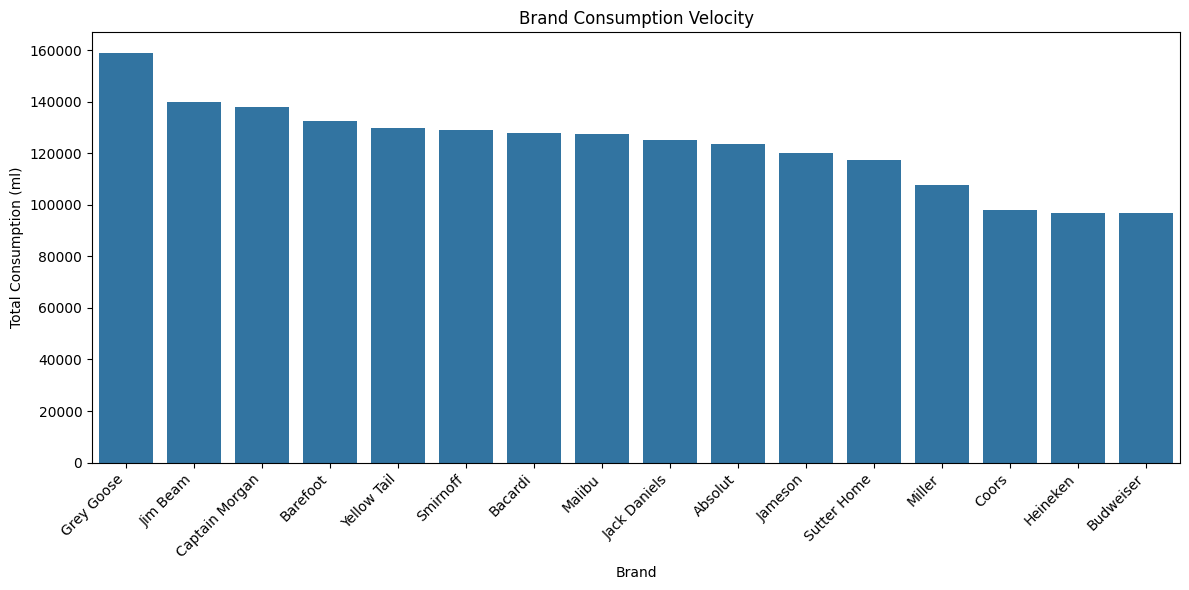

In [48]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=brand_velocity,
    x="Brand Name",
    y="Consumed (ml)"
)

plt.xticks(rotation=45, ha="right")
plt.title("Brand Consumption Velocity")
plt.xlabel("Brand")
plt.ylabel("Total Consumption (ml)")
plt.tight_layout()
plt.show()

ABC summary

In [49]:
abc_summary = (
    brand_velocity
    .groupby("ABC Class")
    .agg(
        Number_of_Brands=("Brand Name", "count"),
        Total_Consumption_ml=("Consumed (ml)", "sum")
    )
    .reset_index()
)

abc_summary["Consumption Share (%)"] = (
    abc_summary["Total_Consumption_ml"]
    / brand_velocity["Consumed (ml)"].sum()
    * 100
)

abc_summary

,ABC Class,Number_of_Brands,Total_Consumption_ml,Consumption Share (%)
0,A,12,1569183.27,79.707314
1,B,2,205718.65,10.449564
2,C,2,193779.74,9.843122


**Part B — Day-of-Week Analysis**

Average consumption by day

In [50]:
day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

dow_consumption = (
    daily_ts.groupby("Day of Week")["Consumed (ml)"]
    .agg(["mean", "sum"])
    .reindex(day_order)
)

dow_consumption

,mean,sum
Day of Week,,
Monday,53.224733,270807.44
Tuesday,56.017458,279639.15
Wednesday,58.503101,292047.48
Thursday,55.643606,277772.88
Friday,56.826180,283676.29
Saturday,56.474858,281922.49
Sunday,55.584892,282815.93


Plot day-of-week demand

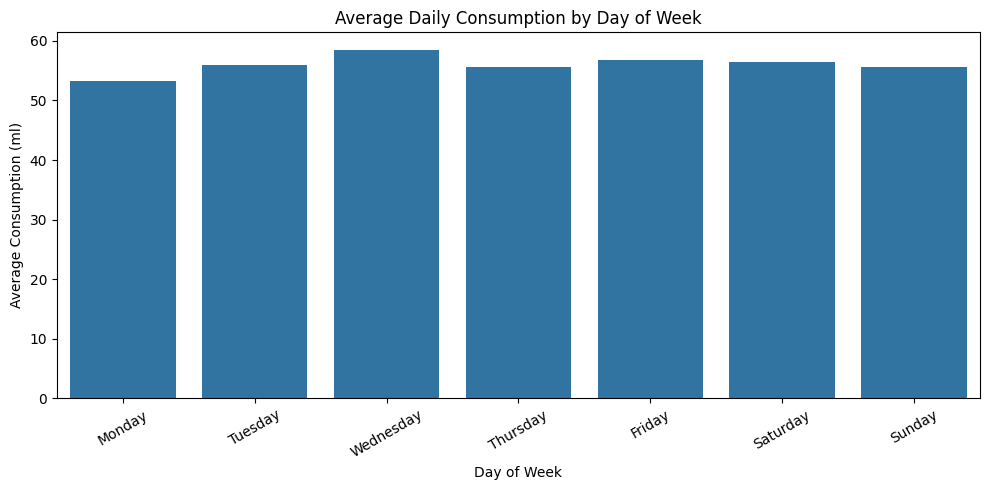

In [51]:
plt.figure(figsize=(10, 5))

sns.barplot(
    x=dow_consumption.index,
    y=dow_consumption["mean"]
)

plt.title("Average Daily Consumption by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Average Consumption (ml)")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

Weekend comparison

In [52]:
weekday_avg = daily_ts[
    ~daily_ts["Day Number"].isin([5, 6])
]["Consumed (ml)"].mean()

weekend_avg = daily_ts[
    daily_ts["Day Number"].isin([5, 6])
]["Consumed (ml)"].mean()

print(f"Weekday average consumption: {weekday_avg:,.2f} ml")
print(f"Weekend average consumption: {weekend_avg:,.2f} ml")

difference = ((weekend_avg - weekday_avg) / weekday_avg) * 100

print(f"Weekend vs weekday difference: {difference:.2f}%")

Weekday average consumption: 56.03 ml
Weekend average consumption: 56.03 ml
Weekend vs weekday difference: -0.01%


**Part C — Historical Stockout Audit**

Identify zero closing balances

In [53]:
stockout_transactions = df[
    df["Closing Balance (ml)"] == 0
].copy()

print("Transactions ending with zero inventory:",
      len(stockout_transactions))

stockout_transactions.head()

Transactions ending with zero inventory: 416


,Date Time Served,Bar Name,Alcohol Type,Brand Name,Opening Balance (ml),Purchase (ml),Consumed (ml),Closing Balance (ml),Calculated Closing,Balance Difference,Date
84,2023-01-05 12:48:00,Taylor's Bar,Beer,Heineken,398.16,0.0,398.16,0.0,-1.023182e-12,1.023182e-12,2023-01-05
102,2023-01-06 11:51:00,Brown's Bar,Rum,Bacardi,145.81,0.0,145.81,0.0,-9.947598e-13,9.947598e-13,2023-01-06
133,2023-01-07 22:34:00,Thomas's Bar,Beer,Coors,161.86,0.0,161.86,0.0,-1.023182e-12,1.023182e-12,2023-01-07
194,2023-01-11 16:04:00,Smith's Bar,Whiskey,Jim Beam,487.92,0.0,487.92,0.0,-1.023182e-12,1.023182e-12,2023-01-11
198,2023-01-11 18:14:00,Johnson's Bar,Whiskey,Jim Beam,319.86,0.0,319.86,0.0,0.000000e+00,0.000000e+00,2023-01-11


Stronger stockout indicator

In [54]:
historical_stockout_candidates = df[
    (df["Closing Balance (ml)"] == 0) &
    (df["Consumed (ml)"] > 0)
].copy()

print(
    "Zero-closing transactions with positive consumption:",
    len(historical_stockout_candidates)
)

historical_stockout_candidates.head()

Zero-closing transactions with positive consumption: 102


,Date Time Served,Bar Name,Alcohol Type,Brand Name,Opening Balance (ml),Purchase (ml),Consumed (ml),Closing Balance (ml),Calculated Closing,Balance Difference,Date
84,2023-01-05 12:48:00,Taylor's Bar,Beer,Heineken,398.16,0.0,398.16,0.0,-1.023182e-12,1.023182e-12,2023-01-05
102,2023-01-06 11:51:00,Brown's Bar,Rum,Bacardi,145.81,0.0,145.81,0.0,-9.947598e-13,9.947598e-13,2023-01-06
133,2023-01-07 22:34:00,Thomas's Bar,Beer,Coors,161.86,0.0,161.86,0.0,-1.023182e-12,1.023182e-12,2023-01-07
194,2023-01-11 16:04:00,Smith's Bar,Whiskey,Jim Beam,487.92,0.0,487.92,0.0,-1.023182e-12,1.023182e-12,2023-01-11
198,2023-01-11 18:14:00,Johnson's Bar,Whiskey,Jim Beam,319.86,0.0,319.86,0.0,0.000000e+00,0.000000e+00,2023-01-11


Stockout candidates by brand

In [55]:
stockout_by_brand = (
    historical_stockout_candidates
    .groupby("Brand Name")
    .agg(
        Stockout_Candidates=("Brand Name", "size"),
        Lost_Demand_Proxy_ml=("Consumed (ml)", "sum")
    )
    .sort_values("Stockout_Candidates", ascending=False)
    .reset_index()
)

stockout_by_brand

,Brand Name,Stockout_Candidates,Lost_Demand_Proxy_ml
0,Yellow Tail,15,3950.45
1,Coors,9,2586.95
2,Jameson,9,1879.80
3,Miller,7,2440.10
4,Jim Beam,7,2088.81
5,Absolut,6,858.32
6,Grey Goose,6,1590.36
7,Budweiser,6,1446.07
8,Smirnoff,6,1264.40
9,Malibu,6,994.40


Stockout candidates by bar

In [56]:
stockout_by_bar = (
    historical_stockout_candidates
    .groupby("Bar Name")
    .size()
    .sort_values(ascending=False)
    .reset_index(name="Stockout Candidates")
)

stockout_by_bar

,Bar Name,Stockout Candidates
0,Taylor's Bar,22
1,Thomas's Bar,21
2,Brown's Bar,19
3,Anderson's Bar,16
4,Smith's Bar,14
5,Johnson's Bar,10


**Part D — One useful EDA visualization**

Consumption trend over time

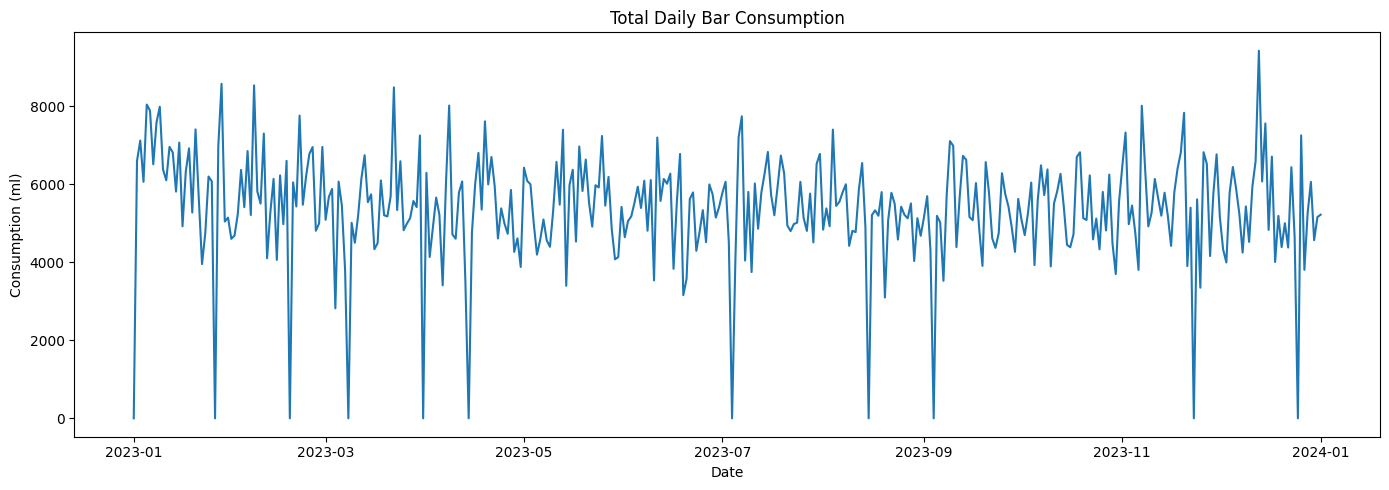

In [57]:
daily_total = (
    daily_ts.groupby("Date")["Consumed (ml)"]
    .sum()
)

plt.figure(figsize=(14, 5))

plt.plot(
    daily_total.index,
    daily_total.values
)

plt.title("Total Daily Bar Consumption")
plt.xlabel("Date")
plt.ylabel("Consumption (ml)")
plt.tight_layout()
plt.show()

EDA summary

In [58]:
print("========== EDA SUMMARY ==========")

print(f"Number of brands: {daily_ts['Brand Name'].nunique()}")
print(f"Number of bars: {daily_ts['Bar Name'].nunique()}")

print("\nABC Classification:")
print(abc_summary)

print("\nDay-of-Week Average Consumption:")
print(dow_consumption["mean"])

print("\nHistorical Stockout Candidates:")
print(len(historical_stockout_candidates))

========== EDA SUMMARY ==========
Number of brands: 16
Number of bars: 6

ABC Classification:
  ABC Class  Number_of_Brands  Total_Consumption_ml  Consumption Share (%)
0         A                12            1569183.27              79.707314
1         B                 2             205718.65              10.449564
2         C                 2             193779.74               9.843122

Day-of-Week Average Consumption:
Day of Week
Monday       53.224733
Tuesday      56.017458
Wednesday    58.503101
Thursday     55.643606
Friday       56.826180
Saturday     56.474858
Sunday       55.584892
Name: mean, dtype: float64

Historical Stockout Candidates:
102


# Step 3 — Demand Forecasting

The objective is to forecast daily consumption for each Bar × Brand series.

Because the data contains many zero-consumption days, the forecasting workflow uses chronological walk-forward validation and tests both regular baselines and intermittent-demand methods.

The final model is selected using development-period results and evaluated once on a locked final test period.


Install LightGBM for model comparison


In [59]:
# Install LightGBM in Google Colab
!pip -q install lightgbm

# Core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Statistical forecasting
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# Machine learning
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
from lightgbm import LGBMRegressor

import warnings
warnings.filterwarnings("ignore")

print("Forecasting libraries loaded successfully.")

Forecasting libraries loaded successfully.


## Step 3.1 — Clean Walk-Forward Validation


CLEAN WALK-FORWARD VALIDATION
Raw daily-panel observations : 35,136
Bar-Brand series             : 96

FIXED FINAL HOLDOUT
Total calendar days : 366
Development days    : 292
Final test days     : 74
Development period  : 2023-01-01 -> 2023-10-19
FINAL TEST PERIOD   : 2023-10-20 -> 2024-01-01

FEATURE DATASET
Feature observations : 32,448
Feature columns      : 44
Zero-demand %        : 84.01%
Positive-demand %    : 15.99%

WALK-FORWARD FOLDS
Fold 1: Train <= 2023-06-29 | Validate 2023-06-30 -> 2023-07-27
Fold 2: Train <= 2023-07-27 | Validate 2023-07-28 -> 2023-08-24
Fold 3: Train <= 2023-08-24 | Validate 2023-08-25 -> 2023-09-21
Fold 4: Train <= 2023-09-21 | Validate 2023-09-22 -> 2023-10-19

Models:
 - Seasonal Naive 7
 - Rolling Mean 7
 - Rolling Mean 14
 - Random Forest
 - LightGBM

FOLD 1
Train rows : 14,592 | Validation rows : 2,688

FOLD 2
Train rows : 17,280 | Validation rows : 2,688

FOLD 3
Train rows : 19,968 | Validation rows : 2,688

FOLD 4
Train rows : 22,656 | Validation

,Fold,Model,MAE,WAPE,Actual Mean,Forecast Mean,Positive Forecast %
0,1,Seasonal Naive 7,96.517,173.173,55.734,55.760,16.146
1,1,Rolling Mean 7,92.426,165.834,55.734,55.952,67.299
2,1,Rolling Mean 14,92.371,165.735,55.734,55.003,86.198
3,1,Random Forest,97.172,174.349,55.734,61.891,100.000
4,1,LightGBM,95.599,171.528,55.734,60.360,99.591
5,2,Seasonal Naive 7,97.878,180.333,54.276,54.539,15.588
6,2,Rolling Mean 7,91.226,168.079,54.276,54.484,65.923
7,2,Rolling Mean 14,91.982,169.470,54.276,55.780,85.193
8,2,Random Forest,96.276,177.382,54.276,61.245,100.000
9,2,LightGBM,93.099,171.528,54.276,56.954,99.777



AGGREGATED WALK-FORWARD PERFORMANCE


,Model,Avg_MAE,Avg_WAPE,Avg_Actual,Avg_Forecast,Avg_Positive_Forecast
0,Rolling Mean 14,91.248,166.376,54.849,54.540,85.993
1,Rolling Mean 7,91.332,166.533,54.849,54.701,67.011
2,LightGBM,94.749,172.733,54.849,59.395,99.795
3,Random Forest,96.294,175.586,54.849,61.200,100.000
4,Seasonal Naive 7,96.528,176.016,54.849,54.573,15.765



MODEL STABILITY ACROSS HISTORICAL PERIODS


,Model,WAPE_Mean,WAPE_Std,MAE_Mean,MAE_Std
2,Rolling Mean 14,166.376,2.115,91.248,1.427
3,Rolling Mean 7,166.533,1.517,91.332,0.924
0,LightGBM,172.733,2.283,94.749,2.455
1,Random Forest,175.586,1.902,96.294,0.754
4,Seasonal Naive 7,176.016,3.093,96.528,1.314


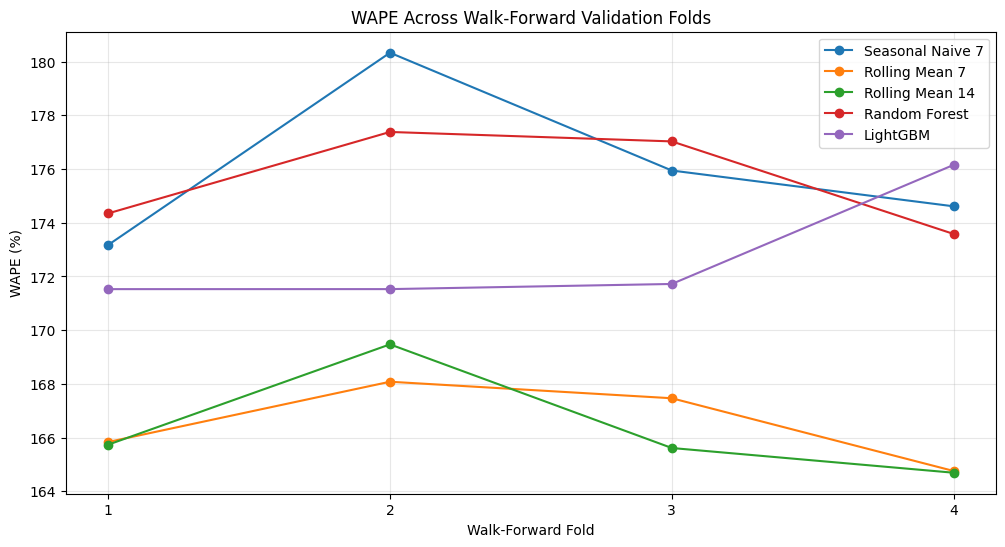

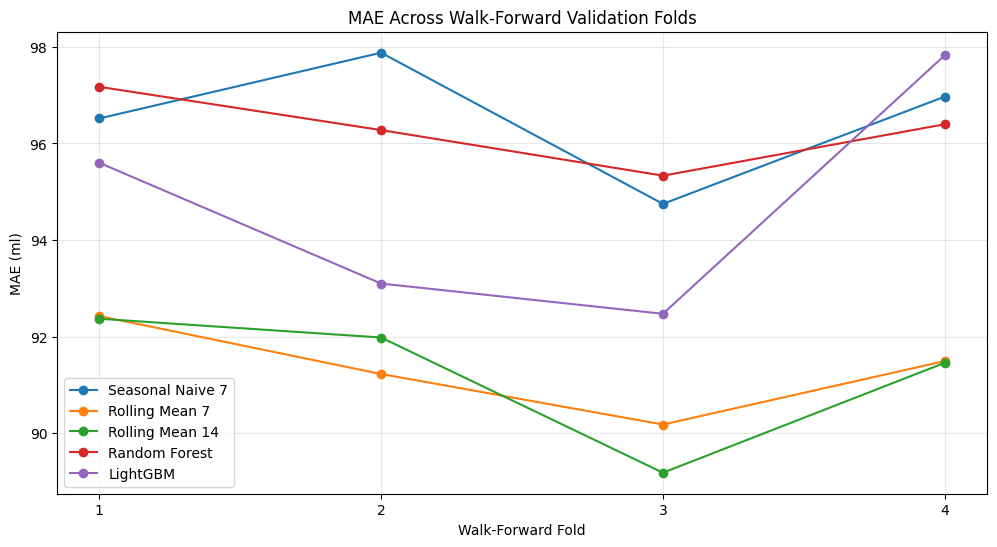


FINAL TEST PROTECTION CHECK
Final test rows currently held out: 7,104
Final test period remains: 2023-10-20 -> 2024-01-01

IMPORTANT: No model has been selected using the final test data.

CURRENT VALIDATION CANDIDATE
Model: Rolling Mean 14
Average validation MAE  : 91.248 ml
Average validation WAPE  : 166.376%
Average forecast         : 54.540 ml
Average positive forecast: 85.99%

NEXT STEP
Do NOT touch the final test set yet.
Use these walk-forward results to decide what we tune next.
The next tuning stage should improve the selected candidate using ONLY the historical development period.


In [60]:
# ============================================================
# STEP 3 - CLEAN WALK-FORWARD VALIDATION
# ============================================================
# Purpose:
# 1. Build leakage-safe forecasting features
# 2. Reserve the FINAL 20% of dates as a completely untouched test set
# 3. Use 4 expanding-window walk-forward validation folds
# 4. Compare:
#       - Seasonal Naive (7-day lag)
#       - Rolling Mean 7-day
#       - Rolling Mean 14-day
#       - Random Forest
#       - LightGBM
# 5. Select model ONLY from historical walk-forward validation
#
# IMPORTANT:
# The final 20% test set is NOT used for model selection.
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

# LightGBM
try:
    from lightgbm import LGBMRegressor
    LIGHTGBM_AVAILABLE = True
except Exception:
    LIGHTGBM_AVAILABLE = False
    print("WARNING: LightGBM is not available. It will be skipped.")

# ------------------------------------------------------------
# 1. CHECK REQUIRED DATA
# ------------------------------------------------------------

required_cols = ['Date', 'Bar Name', 'Brand Name', 'Consumed (ml)']

missing_cols = [c for c in required_cols if c not in daily_ts.columns]

if missing_cols:
    raise ValueError(
        f"daily_ts is missing required columns: {missing_cols}"
    )

print("=" * 70)
print("CLEAN WALK-FORWARD VALIDATION")
print("=" * 70)

# Work on a fresh copy so previous tuning does not contaminate this run.
wf_df = daily_ts[required_cols].copy()

wf_df['Date'] = pd.to_datetime(wf_df['Date'])
wf_df['Consumed (ml)'] = pd.to_numeric(
    wf_df['Consumed (ml)'],
    errors='coerce'
).fillna(0.0)

wf_df = wf_df.sort_values(
    ['Bar Name', 'Brand Name', 'Date']
).reset_index(drop=True)

print(f"Raw daily-panel observations : {len(wf_df):,}")
print(f"Bar-Brand series             : {wf_df[['Bar Name', 'Brand Name']].drop_duplicates().shape[0]}")

# ------------------------------------------------------------
# 2. DEFINE THE FINAL TEST PERIOD BEFORE FEATURE ENGINEERING
# ------------------------------------------------------------
# This is important.
# The 80/20 boundary is based on the COMPLETE calendar,
# not after dropping rows because of lag features.

all_dates = np.sort(wf_df['Date'].unique())

n_dates = len(all_dates)

final_test_index = int(np.floor(n_dates * 0.80))

final_test_start = pd.Timestamp(all_dates[final_test_index])

dev_dates = all_dates[all_dates < final_test_start]
final_test_dates = all_dates[all_dates >= final_test_start]

print("\n" + "=" * 70)
print("FIXED FINAL HOLDOUT")
print("=" * 70)

print(f"Total calendar days : {n_dates}")
print(f"Development days    : {len(dev_dates)}")
print(f"Final test days     : {len(final_test_dates)}")
print(f"Development period  : {pd.Timestamp(dev_dates[0]).date()} -> {pd.Timestamp(dev_dates[-1]).date()}")
print(f"FINAL TEST PERIOD   : {final_test_start.date()} -> {pd.Timestamp(final_test_dates[-1]).date()}")

# ------------------------------------------------------------
# 3. LEAKAGE-SAFE FEATURE ENGINEERING
# ------------------------------------------------------------
# All demand-based features use SHIFT(1) or earlier.
# Therefore today's target is never included in today's features.

group_keys = ['Bar Name', 'Brand Name']

group_consumption = wf_df.groupby(group_keys)['Consumed (ml)']

# Lags
for lag in [1, 2, 3, 7, 14, 21, 28]:
    wf_df[f'lag_{lag}'] = group_consumption.shift(lag)

# Rolling statistics based ONLY on previous observations
for window in [7, 14, 28]:
    wf_df[f'rolling_mean_{window}'] = (
        wf_df.groupby(group_keys)['Consumed (ml)']
        .transform(
            lambda s: s.shift(1).rolling(
                window=window,
                min_periods=window
            ).mean()
        )
    )

    wf_df[f'rolling_std_{window}'] = (
        wf_df.groupby(group_keys)['Consumed (ml)']
        .transform(
            lambda s: s.shift(1).rolling(
                window=window,
                min_periods=window
            ).std()
        )
    )

    # Fraction of active-demand days in recent history
    wf_df[f'active_rate_{window}'] = (
        wf_df.groupby(group_keys)['Consumed (ml)']
        .transform(
            lambda s: s.shift(1).gt(0).rolling(
                window=window,
                min_periods=window
            ).mean()
        )
    )

# Calendar features
wf_df['dayofweek'] = wf_df['Date'].dt.dayofweek
wf_df['is_weekend'] = wf_df['dayofweek'].isin([4, 5, 6]).astype(int)

# Cyclical weekly representation
wf_df['dow_sin'] = np.sin(
    2 * np.pi * wf_df['dayofweek'] / 7
)
wf_df['dow_cos'] = np.cos(
    2 * np.pi * wf_df['dayofweek'] / 7
)

# Annual seasonality representation
day_of_year = wf_df['Date'].dt.dayofyear

wf_df['doy_sin'] = np.sin(
    2 * np.pi * day_of_year / 365.25
)

wf_df['doy_cos'] = np.cos(
    2 * np.pi * day_of_year / 365.25
)

# ------------------------------------------------------------
# 4. ONE-HOT ENCODE STATIC IDENTIFIERS
# ------------------------------------------------------------

wf_df = pd.get_dummies(
    wf_df,
    columns=['Bar Name', 'Brand Name'],
    drop_first=False,
    dtype=float
)

# ------------------------------------------------------------
# 5. REMOVE ROWS THAT DO NOT HAVE ENOUGH HISTORY
# ------------------------------------------------------------

feature_exclude = [
    'Date',
    'Consumed (ml)'
]

feature_cols = [
    c for c in wf_df.columns
    if c not in feature_exclude
]

wf_model = wf_df.dropna(
    subset=[
        c for c in feature_cols
        if c.startswith('lag_')
        or c.startswith('rolling_')
        or c.startswith('active_rate_')
    ]
).copy()

wf_model = wf_model.sort_values('Date').reset_index(drop=True)

print("\n" + "=" * 70)
print("FEATURE DATASET")
print("=" * 70)

print(f"Feature observations : {len(wf_model):,}")
print(f"Feature columns      : {len(feature_cols)}")
print(f"Zero-demand %        : {(wf_model['Consumed (ml)'] == 0).mean() * 100:.2f}%")
print(f"Positive-demand %    : {(wf_model['Consumed (ml)'] > 0).mean() * 100:.2f}%")

# ------------------------------------------------------------
# 6. WAPE FUNCTION
# ------------------------------------------------------------

def calculate_wape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    denominator = np.sum(np.abs(y_true))

    if denominator == 0:
        return np.nan

    return (
        np.sum(np.abs(y_true - y_pred))
        / denominator
    ) * 100


# ------------------------------------------------------------
# 7. CREATE EXPANDING WALK-FORWARD FOLDS
# ------------------------------------------------------------
# We use 4 consecutive 28-day validation windows immediately
# before the final untouched test period.
#
# Example:
#
#   TRAIN ----------------> VALIDATE
#   Jan -> Jun               Jul
#   Jan -> Jul               Aug
#   Jan -> Aug               Sep
#   Jan -> Sep               Oct
#
# All validation windows occur BEFORE the final test period.

dev_date_list = pd.Series(
    pd.to_datetime(dev_dates)
).sort_values().tolist()

VALIDATION_WINDOW_DAYS = 28
N_FOLDS = 4

if len(dev_date_list) < VALIDATION_WINDOW_DAYS * (N_FOLDS + 1):
    raise ValueError(
        "Not enough development dates for the requested walk-forward folds."
    )

folds = []

# Build folds backwards from the end of the development period
latest_val_end_idx = len(dev_date_list) - 1

for fold_number in range(N_FOLDS, 0, -1):

    val_end_idx = latest_val_end_idx - (
        (fold_number - 1) * VALIDATION_WINDOW_DAYS
    )

    val_start_idx = val_end_idx - VALIDATION_WINDOW_DAYS + 1

    # Need at least some training history before validation
    if val_start_idx <= 0:
        continue

    train_end_idx = val_start_idx - 1

    train_end = pd.Timestamp(dev_date_list[train_end_idx])
    val_start = pd.Timestamp(dev_date_list[val_start_idx])
    val_end = pd.Timestamp(dev_date_list[val_end_idx])

    folds.append({
        'fold': len(folds) + 1,
        'train_end': train_end,
        'val_start': val_start,
        'val_end': val_end
    })

# Sort chronologically
folds = sorted(folds, key=lambda x: x['val_start'])

print("\n" + "=" * 70)
print("WALK-FORWARD FOLDS")
print("=" * 70)

for f in folds:
    print(
        f"Fold {f['fold']}: "
        f"Train <= {f['train_end'].date()} | "
        f"Validate {f['val_start'].date()} -> {f['val_end'].date()}"
    )

# ------------------------------------------------------------
# 8. MODEL CONFIGURATION
# ------------------------------------------------------------

models_to_evaluate = [
    'Seasonal Naive 7',
    'Rolling Mean 7',
    'Rolling Mean 14',
    'Random Forest'
]

if LIGHTGBM_AVAILABLE:
    models_to_evaluate.append('LightGBM')

print("\nModels:")
for m in models_to_evaluate:
    print(" -", m)

# ------------------------------------------------------------
# 9. WALK-FORWARD EVALUATION
# ------------------------------------------------------------

all_results = []

for fold_info in folds:

    fold_num = fold_info['fold']
    train_end = fold_info['train_end']
    val_start = fold_info['val_start']
    val_end = fold_info['val_end']

    train_mask = wf_model['Date'] <= train_end
    val_mask = (
        (wf_model['Date'] >= val_start) &
        (wf_model['Date'] <= val_end)
    )

    train_data = wf_model.loc[train_mask].copy()
    val_data = wf_model.loc[val_mask].copy()

    X_train = train_data[feature_cols]
    y_train = train_data['Consumed (ml)']

    X_val = val_data[feature_cols]
    y_val = val_data['Consumed (ml)']

    print("\n" + "=" * 70)
    print(f"FOLD {fold_num}")
    print("=" * 70)

    print(
        f"Train rows : {len(train_data):,} | "
        f"Validation rows : {len(val_data):,}"
    )

    # --------------------------------------------------------
    # MODEL 1 - SEASONAL NAIVE (7-DAY LAG)
    # --------------------------------------------------------

    pred_naive7 = val_data['lag_7'].fillna(
        val_data['lag_1'].median()
    ).clip(lower=0)

    all_results.append({
        'Fold': fold_num,
        'Model': 'Seasonal Naive 7',
        'MAE': mean_absolute_error(y_val, pred_naive7),
        'WAPE': calculate_wape(y_val, pred_naive7),
        'Actual Mean': y_val.mean(),
        'Forecast Mean': pred_naive7.mean(),
        'Positive Forecast %': (pred_naive7 > 0).mean() * 100
    })

    # --------------------------------------------------------
    # MODEL 2 - ROLLING MEAN 7
    # --------------------------------------------------------

    pred_roll7 = val_data['rolling_mean_7'].fillna(0).clip(lower=0)

    all_results.append({
        'Fold': fold_num,
        'Model': 'Rolling Mean 7',
        'MAE': mean_absolute_error(y_val, pred_roll7),
        'WAPE': calculate_wape(y_val, pred_roll7),
        'Actual Mean': y_val.mean(),
        'Forecast Mean': pred_roll7.mean(),
        'Positive Forecast %': (pred_roll7 > 0).mean() * 100
    })

    # --------------------------------------------------------
    # MODEL 3 - ROLLING MEAN 14
    # --------------------------------------------------------

    pred_roll14 = val_data['rolling_mean_14'].fillna(0).clip(lower=0)

    all_results.append({
        'Fold': fold_num,
        'Model': 'Rolling Mean 14',
        'MAE': mean_absolute_error(y_val, pred_roll14),
        'WAPE': calculate_wape(y_val, pred_roll14),
        'Actual Mean': y_val.mean(),
        'Forecast Mean': pred_roll14.mean(),
        'Positive Forecast %': (pred_roll14 > 0).mean() * 100
    })

    # --------------------------------------------------------
    # MODEL 4 - RANDOM FOREST
    # --------------------------------------------------------

    rf_model = RandomForestRegressor(
        n_estimators=250,
        max_depth=12,
        min_samples_leaf=4,
        max_features='sqrt',
        random_state=42,
        n_jobs=-1
    )

    rf_model.fit(X_train, y_train)

    pred_rf = np.clip(
        rf_model.predict(X_val),
        0,
        None
    )

    all_results.append({
        'Fold': fold_num,
        'Model': 'Random Forest',
        'MAE': mean_absolute_error(y_val, pred_rf),
        'WAPE': calculate_wape(y_val, pred_rf),
        'Actual Mean': y_val.mean(),
        'Forecast Mean': pred_rf.mean(),
        'Positive Forecast %': (pred_rf > 0).mean() * 100
    })

    # --------------------------------------------------------
    # MODEL 5 - LIGHTGBM
    # --------------------------------------------------------

    if LIGHTGBM_AVAILABLE:

        lgb_model = LGBMRegressor(
            objective='regression',
            n_estimators=500,
            learning_rate=0.03,
            num_leaves=31,
            max_depth=-1,
            min_child_samples=30,
            subsample=0.85,
            colsample_bytree=0.85,
            reg_alpha=0.1,
            reg_lambda=0.5,
            random_state=42,
            n_jobs=-1,
            verbosity=-1
        )

        lgb_model.fit(X_train, y_train)

        pred_lgb = np.clip(
            lgb_model.predict(X_val),
            0,
            None
        )

        all_results.append({
            'Fold': fold_num,
            'Model': 'LightGBM',
            'MAE': mean_absolute_error(y_val, pred_lgb),
            'WAPE': calculate_wape(y_val, pred_lgb),
            'Actual Mean': y_val.mean(),
            'Forecast Mean': pred_lgb.mean(),
            'Positive Forecast %': (pred_lgb > 0).mean() * 100
        })


# ------------------------------------------------------------
# 10. RESULTS
# ------------------------------------------------------------

walk_forward_results = pd.DataFrame(all_results)

print("\n" + "=" * 70)
print("WALK-FORWARD RESULTS BY FOLD")
print("=" * 70)

display(
    walk_forward_results.round(3)
)

# ------------------------------------------------------------
# 11. AGGREGATE PERFORMANCE ACROSS ALL VALIDATION WINDOWS
# ------------------------------------------------------------

walk_forward_summary = (
    walk_forward_results
    .groupby('Model')
    .agg(
        Avg_MAE=('MAE', 'mean'),
        Avg_WAPE=('WAPE', 'mean'),
        Avg_Actual=('Actual Mean', 'mean'),
        Avg_Forecast=('Forecast Mean', 'mean'),
        Avg_Positive_Forecast=('Positive Forecast %', 'mean')
    )
    .reset_index()
    .sort_values(
        ['Avg_WAPE', 'Avg_MAE'],
        ascending=[True, True]
    )
    .reset_index(drop=True)
)

print("\n" + "=" * 70)
print("AGGREGATED WALK-FORWARD PERFORMANCE")
print("=" * 70)

display(
    walk_forward_summary.round(3)
)

# ------------------------------------------------------------
# 12. CHECK MODEL STABILITY
# ------------------------------------------------------------
# We don't only want a good average.
# We also want to see whether a model behaves consistently
# across different historical periods.

stability_table = (
    walk_forward_results
    .groupby('Model')
    .agg(
        WAPE_Mean=('WAPE', 'mean'),
        WAPE_Std=('WAPE', 'std'),
        MAE_Mean=('MAE', 'mean'),
        MAE_Std=('MAE', 'std')
    )
    .reset_index()
    .sort_values('WAPE_Mean')
)

print("\n" + "=" * 70)
print("MODEL STABILITY ACROSS HISTORICAL PERIODS")
print("=" * 70)

display(
    stability_table.round(3)
)

# ------------------------------------------------------------
# 13. PLOT WAPE ACROSS WALK-FORWARD FOLDS
# ------------------------------------------------------------

plt.figure(figsize=(12, 6))

for model_name in walk_forward_results['Model'].unique():

    model_subset = walk_forward_results[
        walk_forward_results['Model'] == model_name
    ]

    plt.plot(
        model_subset['Fold'],
        model_subset['WAPE'],
        marker='o',
        label=model_name
    )

plt.xlabel("Walk-Forward Fold")
plt.ylabel("WAPE (%)")
plt.title("WAPE Across Walk-Forward Validation Folds")
plt.xticks(
    sorted(walk_forward_results['Fold'].unique())
)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# ------------------------------------------------------------
# 14. PLOT MAE ACROSS WALK-FORWARD FOLDS
# ------------------------------------------------------------

plt.figure(figsize=(12, 6))

for model_name in walk_forward_results['Model'].unique():

    model_subset = walk_forward_results[
        walk_forward_results['Model'] == model_name
    ]

    plt.plot(
        model_subset['Fold'],
        model_subset['MAE'],
        marker='o',
        label=model_name
    )

plt.xlabel("Walk-Forward Fold")
plt.ylabel("MAE (ml)")
plt.title("MAE Across Walk-Forward Validation Folds")
plt.xticks(
    sorted(walk_forward_results['Fold'].unique())
)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# ------------------------------------------------------------
# 15. FINAL TEST IS STILL UNTOUCHED
# ------------------------------------------------------------

final_test_check = wf_model[
    wf_model['Date'] >= final_test_start
].copy()

print("\n" + "=" * 70)
print("FINAL TEST PROTECTION CHECK")
print("=" * 70)

print(
    f"Final test rows currently held out: "
    f"{len(final_test_check):,}"
)

print(
    f"Final test period remains: "
    f"{final_test_start.date()} -> "
    f"{final_test_check['Date'].max().date()}"
)

print(
    "\nIMPORTANT: No model has been selected using the final test data."
)

# ------------------------------------------------------------
# 16. IDENTIFY THE CURRENT VALIDATION CANDIDATE
# ------------------------------------------------------------
# This is NOT a final-test winner.
# It is simply the model that currently has the lowest
# historical walk-forward WAPE.

current_validation_candidate = walk_forward_summary.iloc[0]['Model']

print("\n" + "=" * 70)
print("CURRENT VALIDATION CANDIDATE")
print("=" * 70)

print(f"Model: {current_validation_candidate}")

candidate_row = walk_forward_summary.iloc[0]

print(
    f"Average validation MAE  : "
    f"{candidate_row['Avg_MAE']:.3f} ml"
)

print(
    f"Average validation WAPE  : "
    f"{candidate_row['Avg_WAPE']:.3f}%"
)

print(
    f"Average forecast         : "
    f"{candidate_row['Avg_Forecast']:.3f} ml"
)

print(
    f"Average positive forecast: "
    f"{candidate_row['Avg_Positive_Forecast']:.2f}%"
)

print("\n" + "=" * 70)
print("NEXT STEP")
print("=" * 70)

print(
    "Do NOT touch the final test set yet."
)

print(
    "Use these walk-forward results to decide what we tune next."
)

print(
    "The next tuning stage should improve the selected candidate "
    "using ONLY the historical development period."
)

Define evaluation metrics

In [61]:
def calculate_wape(actual, predicted):
    actual = np.asarray(actual)
    predicted = np.asarray(predicted)

    denominator = np.sum(np.abs(actual))

    if denominator == 0:
        return np.nan

    return np.sum(np.abs(actual - predicted)) / denominator


def calculate_metrics(actual, predicted):
    actual = np.asarray(actual)
    predicted = np.asarray(predicted)

    mae = mean_absolute_error(actual, predicted)
    wape = calculate_wape(actual, predicted)

    return mae, wape

Define forecasting features

In [62]:
FEATURE_COLUMNS = [
    "lag_1",
    "lag_7",
    "lag_14",
    "rolling_mean_7",
    "rolling_std_7",
    "dayofweek",
    "is_weekend"
]

def create_forecasting_features(series_df):
    data = series_df.copy()
    data = data.sort_values("Date").reset_index(drop=True)

    # Lag features
    data["lag_1"] = data["Consumed (ml)"].shift(1)
    data["lag_7"] = data["Consumed (ml)"].shift(7)
    data["lag_14"] = data["Consumed (ml)"].shift(14)

    # Rolling features
    data["rolling_mean_7"] = (
        data["Consumed (ml)"]
        .shift(1)
        .rolling(window=7)
        .mean()
    )

    data["rolling_std_7"] = (
        data["Consumed (ml)"]
        .shift(1)
        .rolling(window=7)
        .std()
    )

    # Calendar features
    data["dayofweek"] = data["Date"].dt.dayofweek

    data["is_weekend"] = (
        data["dayofweek"].isin([5, 6])
        .astype(int)
    )

    return data

Define the model settings

In [63]:
RANDOM_STATE = 42

rf_params = {
    "n_estimators": 300,
    "max_depth": 12,
    "min_samples_leaf": 3,
    "random_state": RANDOM_STATE,
    "n_jobs": -1
}

lgb_params = {
    "n_estimators": 300,
    "learning_rate": 0.03,
    "num_leaves": 15,
    "max_depth": 6,
    "min_child_samples": 10,
    "subsample": 0.9,
    "colsample_bytree": 0.9,
    "reg_alpha": 0.1,
    "reg_lambda": 0.2,
    "random_state": RANDOM_STATE,
    "n_jobs": -1,
    "verbosity": -1
}

print("Model configurations ready.")

Model configurations ready.


## Step 3.2 — Intermittent Demand Forecasting Experiment


INTERMITTENT DEMAND FORECASTING EXPERIMENT
Bar-Brand series: 96
Methods tested   : 9

Running: Same Weekday Mean 4W

Running: Same Weekday Mean 8W

Running: Same Weekday Median 8W

Running: Croston SBA 0.10

Running: Croston SBA 0.20

Running: Croston SBA 0.30

Running: TSB 0.10

Running: TSB 0.20

Running: TSB 0.30

INTERMITTENT MODEL RESULTS BY FOLD


,Fold,Model,MAE,WAPE,Positive-Day MAE,Actual Mean,Forecast Mean,Actual Positive %,Positive Forecast %
0,1,Same Weekday Mean 4W,65.983,118.389,336.590,55.734,13.860,16.109,12.872
1,2,Same Weekday Mean 4W,64.124,118.144,336.284,54.276,13.934,15.551,12.351
2,3,Same Weekday Mean 4W,63.083,117.143,342.107,53.851,13.569,15.141,12.202
3,4,Same Weekday Mean 4W,65.011,117.066,327.927,55.534,13.463,16.332,11.942
4,1,Same Weekday Mean 8W,66.016,118.447,335.434,55.734,13.988,16.109,18.936
5,2,Same Weekday Mean 8W,63.727,117.414,334.836,54.276,13.897,15.551,18.824
6,3,Same Weekday Mean 8W,63.530,117.973,342.619,53.851,13.751,15.141,18.490
7,4,Same Weekday Mean 8W,64.830,116.741,327.176,55.534,13.516,16.332,17.932
8,1,Same Weekday Median 8W,56.237,100.902,344.822,55.734,0.939,16.109,0.818
9,2,Same Weekday Median 8W,55.082,101.486,348.816,54.276,0.873,15.551,0.707



AGGREGATED INTERMITTENT-DEMAND PERFORMANCE


,Model,Avg_MAE,Avg_WAPE,WAPE_Std,Avg_Positive_Day_MAE,Avg_Actual,Avg_Forecast,Avg_Actual_Positive_Pct,Avg_Positive_Forecast_Pct
0,Same Weekday Median 8W,55.503,101.193,0.258,347.192,54.849,0.824,15.783,0.753
1,Same Weekday Mean 8W,64.526,117.644,0.735,335.016,54.849,13.788,15.783,18.545
2,Same Weekday Mean 4W,64.550,117.686,0.679,335.727,54.849,13.706,15.783,12.342
3,Croston SBA 0.30,90.935,165.811,1.923,294.476,54.849,52.946,15.783,100.000
4,TSB 0.20,91.549,166.930,1.659,290.490,54.849,54.951,15.783,100.000
5,TSB 0.30,91.554,166.941,1.740,291.108,54.849,54.904,15.783,100.000
6,Croston SBA 0.20,91.585,166.997,2.094,293.353,54.849,53.941,15.783,100.000
7,TSB 0.10,91.799,167.385,1.827,290.284,54.849,55.173,15.783,100.000
8,Croston SBA 0.10,92.590,168.833,2.392,291.624,54.849,55.484,15.783,100.000



TOP INTERMITTENT METHODS VS CURRENT BASELINE


,Model,MAE,WAPE,Forecast Mean,Positive Forecast %
0,Rolling Mean 14,91.248,166.376,54.540,85.993
1,Same Weekday Median 8W,55.503,101.193,0.824,0.753
2,Same Weekday Mean 8W,64.526,117.644,13.788,18.545
3,Same Weekday Mean 4W,64.550,117.686,13.706,12.342
4,Croston SBA 0.30,90.935,165.811,52.946,100.000
5,TSB 0.20,91.549,166.930,54.951,100.000


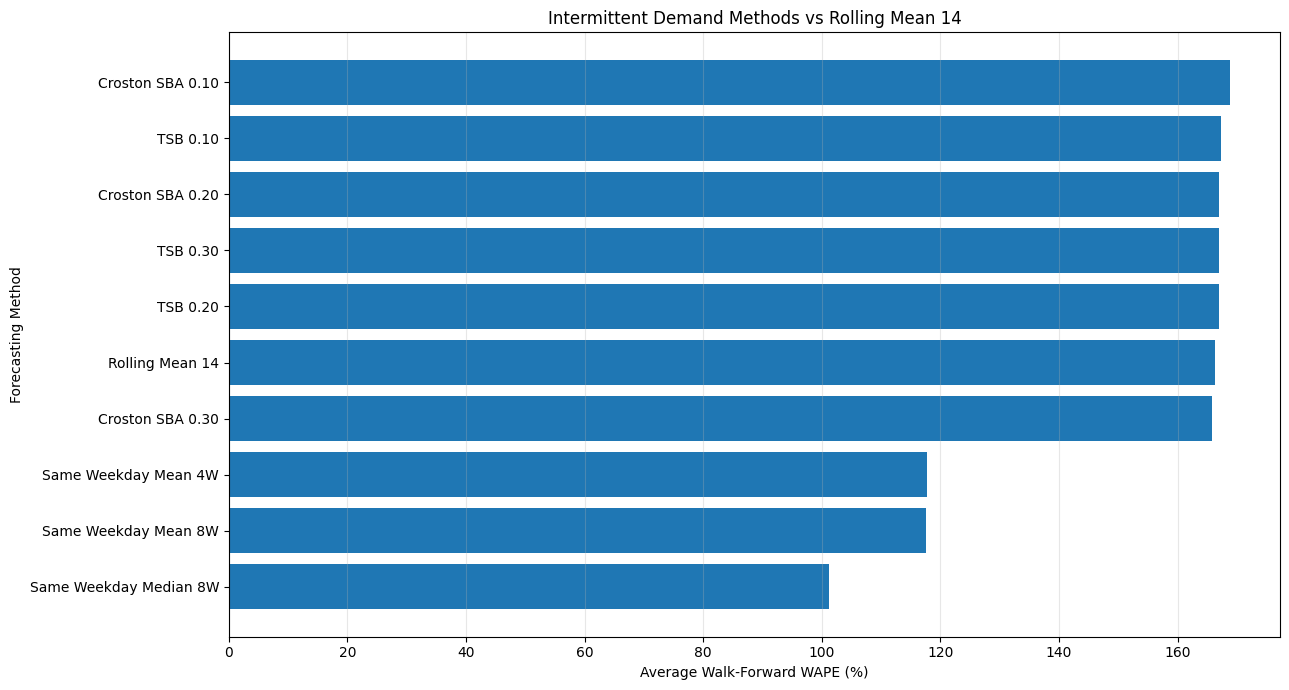

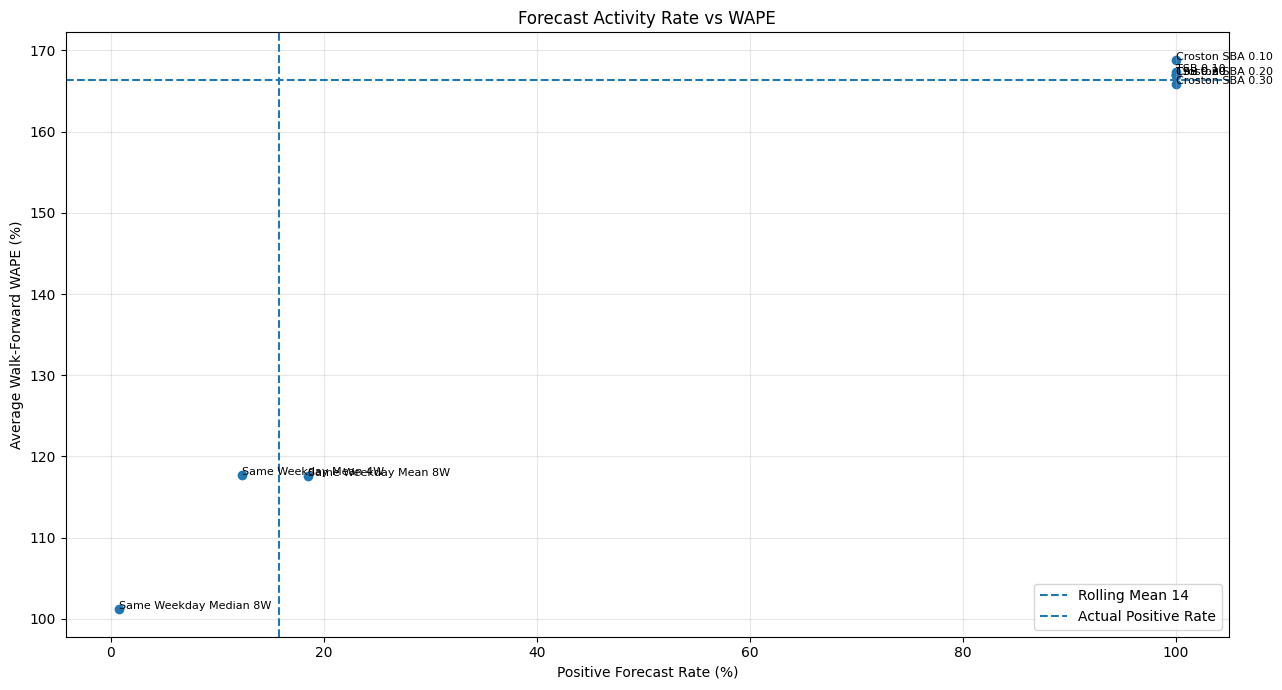


CURRENT INTERMITTENT-DEMAND CANDIDATE
Model                     : Same Weekday Median 8W
Average MAE              : 55.503 ml
Average WAPE             : 101.193%
WAPE standard deviation  : 0.258
Average actual demand    : 54.849 ml
Average forecast         : 0.824 ml
Actual positive rate     : 15.78%
Forecast positive rate   : 0.75%

DECISION
At least one intermittent-demand method improves on Rolling Mean 14.
That method should be examined further before touching the final test set.

FINAL TEST PROTECTION
Final test period remains LOCKED: 2023-10-20 -> 2024-01-01
No final-test observations were used in this model comparison.

Do NOT proceed to Step 4 yet.
First inspect the aggregated table above.


In [64]:
# ================================================================
# STEP 3 - INTERMITTENT DEMAND FORECASTING EXPERIMENT
# ================================================================
#
# Goal:
#   Test forecasting methods that are designed for sparse /
#   intermittent demand.
#
# Methods:
#   1. Same Weekday Mean - previous 4 weeks
#   2. Same Weekday Mean - previous 8 weeks
#   3. Same Weekday Median - previous 8 weeks
#   4. Croston-SBA alpha=0.10
#   5. Croston-SBA alpha=0.20
#   6. Croston-SBA alpha=0.30
#   7. TSB-style alpha=0.10 beta=0.10
#   8. TSB-style alpha=0.20 beta=0.20
#   9. TSB-style alpha=0.30 beta=0.30
#
# Evaluation:
#   - Walk-forward validation only
#   - Same 4 historical folds
#   - Final test remains untouched
#
# ================================================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error


print("=" * 80)
print("INTERMITTENT DEMAND FORECASTING EXPERIMENT")
print("=" * 80)


# ---------------------------------------------------------------
# 1. CHECK SOURCE DATA
# ---------------------------------------------------------------

required_cols = [
    'Date',
    'Bar Name',
    'Brand Name',
    'Consumed (ml)'
]

missing_cols = [
    c for c in required_cols
    if c not in daily_ts.columns
]

if missing_cols:
    raise ValueError(
        f"daily_ts is missing required columns: {missing_cols}"
    )


# ---------------------------------------------------------------
# 2. CLEAN DAILY PANEL
# ---------------------------------------------------------------

intermittent_df = daily_ts[
    required_cols
].copy()

intermittent_df['Date'] = pd.to_datetime(
    intermittent_df['Date']
)

intermittent_df['Consumed (ml)'] = pd.to_numeric(
    intermittent_df['Consumed (ml)'],
    errors='coerce'
).fillna(0.0)

intermittent_df = intermittent_df.sort_values(
    [
        'Bar Name',
        'Brand Name',
        'Date'
    ]
).reset_index(drop=True)


# ---------------------------------------------------------------
# 3. METRICS
# ---------------------------------------------------------------

def calculate_wape(y_true, y_pred):

    y_true = np.asarray(
        y_true,
        dtype=float
    )

    y_pred = np.asarray(
        y_pred,
        dtype=float
    )

    denominator = np.sum(
        np.abs(y_true)
    )

    if denominator == 0:
        return np.nan

    return (
        np.sum(
            np.abs(
                y_true - y_pred
            )
        )
        / denominator
    ) * 100


def positive_day_mae(y_true, y_pred):

    y_true = np.asarray(
        y_true,
        dtype=float
    )

    y_pred = np.asarray(
        y_pred,
        dtype=float
    )

    mask = y_true > 0

    if mask.sum() == 0:
        return np.nan

    return mean_absolute_error(
        y_true[mask],
        y_pred[mask]
    )


# ---------------------------------------------------------------
# 4. INTERMITTENT FORECAST FUNCTIONS
# ---------------------------------------------------------------

def same_weekday_forecast(
    train_dates,
    train_values,
    validation_dates,
    window_weeks=4,
    statistic='mean'
):
    """
    Forecast each validation day using only previous observations
    from the same weekday.

    Example:
        Friday forecast =
        mean/median of previous 4 Fridays.
    """

    history = pd.Series(
        train_values,
        index=pd.to_datetime(train_dates)
    ).sort_index()

    validation_dates = pd.to_datetime(
        validation_dates
    )

    forecasts = []

    for current_date in validation_dates:

        same_weekday_dates = [
            current_date - pd.Timedelta(
                days=7 * i
            )
            for i in range(
                1,
                window_weeks + 1
            )
        ]

        values = []

        for d in same_weekday_dates:

            if d in history.index:

                value = history.loc[d]

                if isinstance(value, pd.Series):
                    value = value.iloc[-1]

                values.append(
                    float(value)
                )

        if len(values) == 0:

            forecast = 0.0

        elif statistic == 'median':

            forecast = float(
                np.median(values)
            )

        else:

            forecast = float(
                np.mean(values)
            )

        forecasts.append(
            max(0.0, forecast)
        )

        # IMPORTANT:
        # Once the actual validation day occurs, it becomes
        # available for the next validation-day forecast.
        history.loc[current_date] = np.nan

    return np.array(
        forecasts,
        dtype=float
    )


def croston_sba_forecast(
    train_values,
    validation_values,
    alpha=0.2
):
    """
    Croston-SBA style intermittent-demand forecast.

    Uses training history for initialization, then updates
    sequentially as actual validation observations become known.
    """

    train_values = np.asarray(
        train_values,
        dtype=float
    )

    validation_values = np.asarray(
        validation_values,
        dtype=float
    )

    positive_positions = np.where(
        train_values > 0
    )[0]

    # No historical demand
    if len(positive_positions) == 0:

        return np.zeros(
            len(validation_values),
            dtype=float
        )

    positive_values = train_values[
        positive_positions
    ]

    # Initial smoothed demand size
    demand_size = float(
        np.mean(
            positive_values
        )
    )

    # Initial average inter-demand interval
    if len(positive_positions) >= 2:

        intervals = np.diff(
            positive_positions
        )

        interval = float(
            np.mean(intervals)
        )

    else:

        interval = float(
            len(train_values)
        )

    interval = max(
        interval,
        1.0
    )

    last_positive_position = int(
        positive_positions[-1]
    )

    forecasts = []

    correction = (
        1.0 - alpha / 2.0
    )

    for i, actual in enumerate(
        validation_values
    ):

        # Forecast BEFORE seeing today's actual
        forecast = (
            correction
            * demand_size
            / interval
        )

        forecasts.append(
            max(0.0, forecast)
        )

        global_position = (
            len(train_values) + i
        )

        # Update after today's actual becomes known
        if actual > 0:

            new_interval = (
                global_position
                - last_positive_position
            )

            demand_size = (
                demand_size
                + alpha
                * (
                    actual
                    - demand_size
                )
            )

            interval = (
                interval
                + alpha
                * (
                    new_interval
                    - interval
                )
            )

            interval = max(
                interval,
                1.0
            )

            last_positive_position = (
                global_position
            )

    return np.array(
        forecasts,
        dtype=float
    )


def tsb_style_forecast(
    train_values,
    validation_values,
    alpha=0.2,
    beta=0.2
):
    """
    TSB-style intermittent-demand forecast.

    p = probability of demand occurrence
    z = expected demand size conditional on demand

    Forecast:
        p * z

    Both components are updated sequentially.
    """

    train_values = np.asarray(
        train_values,
        dtype=float
    )

    validation_values = np.asarray(
        validation_values,
        dtype=float
    )

    positive_mask = (
        train_values > 0
    )

    positive_count = (
        positive_mask.sum()
    )

    # No positive history
    if positive_count == 0:

        return np.zeros(
            len(validation_values),
            dtype=float
        )

    # Initial occurrence probability
    probability = (
        positive_count
        / len(train_values)
    )

    # Initial positive demand size
    demand_size = float(
        train_values[
            positive_mask
        ].mean()
    )

    forecasts = []

    for actual in validation_values:

        # Forecast BEFORE today's actual
        forecast = (
            probability
            * demand_size
        )

        forecasts.append(
            max(0.0, forecast)
        )

        # Observe today's occurrence
        occurrence = (
            1.0 if actual > 0 else 0.0
        )

        # Update probability
        probability = (
            probability
            + alpha
            * (
                occurrence
                - probability
            )
        )

        # Update demand size only on positive demand
        if actual > 0:

            demand_size = (
                demand_size
                + beta
                * (
                    actual
                    - demand_size
                )
            )

    return np.array(
        forecasts,
        dtype=float
    )


# ---------------------------------------------------------------
# 5. METHOD DEFINITIONS
# ---------------------------------------------------------------

methods = {

    'Same Weekday Mean 4W':
        ('same_weekday_mean', 4),

    'Same Weekday Mean 8W':
        ('same_weekday_mean', 8),

    'Same Weekday Median 8W':
        ('same_weekday_median', 8),

    'Croston SBA 0.10':
        ('croston', 0.10),

    'Croston SBA 0.20':
        ('croston', 0.20),

    'Croston SBA 0.30':
        ('croston', 0.30),

    'TSB 0.10':
        ('tsb', (0.10, 0.10)),

    'TSB 0.20':
        ('tsb', (0.20, 0.20)),

    'TSB 0.30':
        ('tsb', (0.30, 0.30))
}


# ---------------------------------------------------------------
# 6. IDENTIFY 96 SERIES
# ---------------------------------------------------------------

series_list = (
    intermittent_df[
        [
            'Bar Name',
            'Brand Name'
        ]
    ]
    .drop_duplicates()
    .sort_values(
        [
            'Bar Name',
            'Brand Name'
        ]
    )
    .values
    .tolist()
)

print(
    f"Bar-Brand series: {len(series_list)}"
)

print(
    f"Methods tested   : {len(methods)}"
)


# ---------------------------------------------------------------
# 7. WALK-FORWARD EVALUATION
# ---------------------------------------------------------------

all_intermit_results = []

prediction_store = []


for method_name, method_config in methods.items():

    print(
        f"\nRunning: {method_name}"
    )

    for fold_info in folds:

        fold_number = fold_info['fold']

        train_end = fold_info['train_end']
        val_start = fold_info['val_start']
        val_end = fold_info['val_end']

        fold_actual = []
        fold_forecast = []

        # -------------------------------------------------------
        # EACH BAR-BRAND SERIES
        # -------------------------------------------------------

        for bar_name, brand_name in series_list:

            series_data = intermittent_df[
                (
                    intermittent_df['Bar Name']
                    == bar_name
                )
                &
                (
                    intermittent_df['Brand Name']
                    == brand_name
                )
            ].sort_values(
                'Date'
            )

            train_series = series_data[
                series_data['Date']
                <= train_end
            ]

            validation_series = series_data[
                (
                    series_data['Date']
                    >= val_start
                )
                &
                (
                    series_data['Date']
                    <= val_end
                )
            ]

            if (
                len(train_series) == 0
                or len(validation_series) == 0
            ):
                continue

            train_dates = (
                train_series['Date']
                .values
            )

            train_values = (
                train_series['Consumed (ml)']
                .values
            )

            validation_dates = (
                validation_series['Date']
                .values
            )

            validation_values = (
                validation_series['Consumed (ml)']
                .values
            )

            method_type, parameter = (
                method_config
            )

            # ---------------------------------------------------
            # FORECAST
            # ---------------------------------------------------

            if method_type == (
                'same_weekday_mean'
            ):

                predictions = (
                    same_weekday_forecast(
                        train_dates,
                        train_values,
                        validation_dates,
                        window_weeks=parameter,
                        statistic='mean'
                    )
                )

            elif method_type == (
                'same_weekday_median'
            ):

                predictions = (
                    same_weekday_forecast(
                        train_dates,
                        train_values,
                        validation_dates,
                        window_weeks=parameter,
                        statistic='median'
                    )
                )

            elif method_type == (
                'croston'
            ):

                predictions = (
                    croston_sba_forecast(
                        train_values,
                        validation_values,
                        alpha=parameter
                    )
                )

            elif method_type == (
                'tsb'
            ):

                predictions = (
                    tsb_style_forecast(
                        train_values,
                        validation_values,
                        alpha=parameter[0],
                        beta=parameter[1]
                    )
                )

            else:

                raise ValueError(
                    f"Unknown method: {method_type}"
                )

            predictions = np.clip(
                predictions,
                0,
                None
            )

            fold_actual.extend(
                validation_values.tolist()
            )

            fold_forecast.extend(
                predictions.tolist()
            )

            # Keep a small amount of detail for later plots
            prediction_store.append({

                'Method':
                    method_name,

                'Fold':
                    fold_number,

                'Bar Name':
                    bar_name,

                'Brand Name':
                    brand_name,

                'Date':
                    validation_dates,

                'Actual':
                    validation_values,

                'Forecast':
                    predictions
            })


        # -------------------------------------------------------
        # FOLD METRICS
        # -------------------------------------------------------

        fold_actual = np.asarray(
            fold_actual,
            dtype=float
        )

        fold_forecast = np.asarray(
            fold_forecast,
            dtype=float
        )

        all_intermit_results.append({

            'Fold':
                fold_number,

            'Model':
                method_name,

            'MAE':
                mean_absolute_error(
                    fold_actual,
                    fold_forecast
                ),

            'WAPE':
                calculate_wape(
                    fold_actual,
                    fold_forecast
                ),

            'Positive-Day MAE':
                positive_day_mae(
                    fold_actual,
                    fold_forecast
                ),

            'Actual Mean':
                fold_actual.mean(),

            'Forecast Mean':
                fold_forecast.mean(),

            'Actual Positive %':
                (
                    fold_actual > 0
                ).mean() * 100,

            'Positive Forecast %':
                (
                    fold_forecast > 0
                ).mean() * 100
        })


# ---------------------------------------------------------------
# 8. RESULTS
# ---------------------------------------------------------------

intermittent_results_df = pd.DataFrame(
    all_intermit_results
)

print("\n" + "=" * 80)
print("INTERMITTENT MODEL RESULTS BY FOLD")
print("=" * 80)

display(
    intermittent_results_df.round(3)
)


# ---------------------------------------------------------------
# 9. AGGREGATED PERFORMANCE
# ---------------------------------------------------------------

intermittent_summary = (

    intermittent_results_df

    .groupby('Model')

    .agg(

        Avg_MAE=(
            'MAE',
            'mean'
        ),

        Avg_WAPE=(
            'WAPE',
            'mean'
        ),

        WAPE_Std=(
            'WAPE',
            'std'
        ),

        Avg_Positive_Day_MAE=(
            'Positive-Day MAE',
            'mean'
        ),

        Avg_Actual=(
            'Actual Mean',
            'mean'
        ),

        Avg_Forecast=(
            'Forecast Mean',
            'mean'
        ),

        Avg_Actual_Positive_Pct=(
            'Actual Positive %',
            'mean'
        ),

        Avg_Positive_Forecast_Pct=(
            'Positive Forecast %',
            'mean'
        )
    )

    .reset_index()

    .sort_values(
        [
            'Avg_WAPE',
            'Avg_MAE'
        ]
    )

    .reset_index(drop=True)
)

print("\n" + "=" * 80)
print("AGGREGATED INTERMITTENT-DEMAND PERFORMANCE")
print("=" * 80)

display(
    intermittent_summary.round(3)
)


# ---------------------------------------------------------------
# 10. CURRENT BASELINE
# ---------------------------------------------------------------

rolling14_row = walk_forward_summary[
    walk_forward_summary['Model']
    == 'Rolling Mean 14'
]

if len(rolling14_row) > 0:

    baseline_mae = (
        rolling14_row.iloc[0]['Avg_MAE']
    )

    baseline_wape = (
        rolling14_row.iloc[0]['Avg_WAPE']
    )

    baseline_forecast = (
        rolling14_row.iloc[0]['Avg_Forecast']
    )

    baseline_positive = (
    rolling14_row.iloc[0]
    ['Avg_Positive_Forecast']
)

else:

    baseline_mae = np.nan
    baseline_wape = np.nan
    baseline_forecast = np.nan
    baseline_positive = np.nan


# ---------------------------------------------------------------
# 11. TOP INTERMITTENT METHODS
# ---------------------------------------------------------------

top_candidates = intermittent_summary.head(
    5
).copy()


baseline_comparison = pd.DataFrame({

    'Model':
        [
            'Rolling Mean 14'
        ]
        +
        top_candidates['Model'].tolist(),

    'MAE':
        [
            baseline_mae
        ]
        +
        top_candidates['Avg_MAE'].tolist(),

    'WAPE':
        [
            baseline_wape
        ]
        +
        top_candidates['Avg_WAPE'].tolist(),

    'Forecast Mean':
        [
            baseline_forecast
        ]
        +
        top_candidates['Avg_Forecast'].tolist(),

    'Positive Forecast %':
        [
            baseline_positive
        ]
        +
        top_candidates[
            'Avg_Positive_Forecast_Pct'
        ].tolist()
})


print("\n" + "=" * 80)
print("TOP INTERMITTENT METHODS VS CURRENT BASELINE")
print("=" * 80)

display(
    baseline_comparison.round(3)
)


# ---------------------------------------------------------------
# 12. WAPE COMPARISON PLOT
# ---------------------------------------------------------------

plot_data = pd.concat(
    [
        pd.DataFrame({
            'Model':
                ['Rolling Mean 14'],

            'WAPE':
                [baseline_wape]
        }),

        intermittent_summary[
            ['Model', 'Avg_WAPE']
        ].rename(
            columns={
                'Avg_WAPE': 'WAPE'
            }
        )
    ],
    ignore_index=True
)

plot_data = plot_data.sort_values(
    'WAPE'
).reset_index(
    drop=True
)

plt.figure(
    figsize=(13, 7)
)

plt.barh(
    plot_data['Model'],
    plot_data['WAPE']
)

plt.xlabel(
    'Average Walk-Forward WAPE (%)'
)

plt.ylabel(
    'Forecasting Method'
)

plt.title(
    'Intermittent Demand Methods vs Rolling Mean 14'
)

plt.grid(
    axis='x',
    alpha=0.3
)

plt.tight_layout()

plt.show()


# ---------------------------------------------------------------
# 13. POSITIVE FORECAST RATE
# ---------------------------------------------------------------

plt.figure(
    figsize=(13, 7)
)

plt.scatter(
    intermittent_summary[
        'Avg_Positive_Forecast_Pct'
    ],
    intermittent_summary[
        'Avg_WAPE'
    ]
)

for _, row in intermittent_summary.iterrows():

    plt.annotate(
        row['Model'],
        (
            row['Avg_Positive_Forecast_Pct'],
            row['Avg_WAPE']
        ),
        fontsize=8
    )

plt.axhline(
    baseline_wape,
    linestyle='--',
    label='Rolling Mean 14'
)

plt.axvline(
    intermittent_summary[
        'Avg_Actual_Positive_Pct'
    ].mean(),
    linestyle='--',
    label='Actual Positive Rate'
)

plt.xlabel(
    'Positive Forecast Rate (%)'
)

plt.ylabel(
    'Average Walk-Forward WAPE (%)'
)

plt.title(
    'Forecast Activity Rate vs WAPE'
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.show()


# ---------------------------------------------------------------
# 14. IDENTIFY CURRENT CANDIDATE
# ---------------------------------------------------------------

best_intermittent = (
    intermittent_summary
    .iloc[0]
)

print("\n" + "=" * 80)
print("CURRENT INTERMITTENT-DEMAND CANDIDATE")
print("=" * 80)

print(
    f"Model                     : "
    f"{best_intermittent['Model']}"
)

print(
    f"Average MAE              : "
    f"{best_intermittent['Avg_MAE']:.3f} ml"
)

print(
    f"Average WAPE             : "
    f"{best_intermittent['Avg_WAPE']:.3f}%"
)

print(
    f"WAPE standard deviation  : "
    f"{best_intermittent['WAPE_Std']:.3f}"
)

print(
    f"Average actual demand    : "
    f"{best_intermittent['Avg_Actual']:.3f} ml"
)

print(
    f"Average forecast         : "
    f"{best_intermittent['Avg_Forecast']:.3f} ml"
)

print(
    f"Actual positive rate     : "
    f"{best_intermittent['Avg_Actual_Positive_Pct']:.2f}%"
)

print(
    f"Forecast positive rate   : "
    f"{best_intermittent['Avg_Positive_Forecast_Pct']:.2f}%"
)


# ---------------------------------------------------------------
# 15. DECISION AGAINST BASELINE
# ---------------------------------------------------------------

print("\n" + "=" * 80)
print("DECISION")
print("=" * 80)

if (
    best_intermittent['Avg_WAPE']
    < baseline_wape
):

    print(
        "At least one intermittent-demand method "
        "improves on Rolling Mean 14."
    )

    print(
        "That method should be examined further before "
        "touching the final test set."
    )

else:

    print(
        "The tested intermittent-demand methods do NOT "
        "improve on Rolling Mean 14."
    )

    print(
        "Do not select one merely because it is more advanced."
    )


# ---------------------------------------------------------------
# 16. FINAL TEST PROTECTION
# ---------------------------------------------------------------

print("\n" + "=" * 80)
print("FINAL TEST PROTECTION")
print("=" * 80)

print(
    f"Final test period remains LOCKED: "
    f"{final_test_start.date()} -> "
    f"{wf_model['Date'].max().date()}"
)

print(
    "No final-test observations were used in "
    "this model comparison."
)

print(
    "\nDo NOT proceed to Step 4 yet."
)

print(
    "First inspect the aggregated table above."
)

## Step 3.3 — Final Model Selection

In [65]:
# ============================================================
# STEP 3.3 — FINAL MODEL SELECTION AND FINAL TEST FORECAST
# ============================================================

FINAL_MODEL = "Same Weekday Mean 8W"
FINAL_WINDOW_WEEKS = 8

print("=" * 80)
print("FINAL MODEL")
print("=" * 80)
print(f"Selected model: {FINAL_MODEL}")
print("Final test observations remain untouched during model selection.")

# ------------------------------------------------------------
# Build final-test forecasts using ONLY development-period data
# ------------------------------------------------------------

final_forecasts = []

series_list = (
    daily_ts[
        ["Bar Name", "Brand Name"]
    ]
    .drop_duplicates()
    .sort_values(["Bar Name", "Brand Name"])
    .values
    .tolist()
)

final_test_dates_sorted = pd.to_datetime(
    final_test_dates
)

for bar_name, brand_name in series_list:

    series_data = (
        daily_ts[
            (daily_ts["Bar Name"] == bar_name) &
            (daily_ts["Brand Name"] == brand_name)
        ]
        .sort_values("Date")
        .copy()
    )

    # Development history only
    train_series = series_data[
        series_data["Date"] < final_test_start
    ]

    # Final locked test period
    test_series = series_data[
        series_data["Date"] >= final_test_start
    ].sort_values("Date")

    train_dates = train_series["Date"].values
    train_values = train_series["Consumed (ml)"].values

    test_dates = test_series["Date"].values
    test_actuals = test_series["Consumed (ml)"].values

    predictions = same_weekday_forecast(
        train_dates=train_dates,
        train_values=train_values,
        validation_dates=test_dates,
        window_weeks=FINAL_WINDOW_WEEKS,
        statistic="mean"
    )

    series_result = pd.DataFrame({
        "Date": pd.to_datetime(test_dates),
        "Bar Name": bar_name,
        "Brand Name": brand_name,
        "Consumed (ml)": test_actuals,
        "Forecasted Daily Demand": predictions
    })

    final_forecasts.append(series_result)

# ------------------------------------------------------------
# Combine all 96 series
# ------------------------------------------------------------

final_forecast_results_df = (
    pd.concat(final_forecasts, ignore_index=True)
    .sort_values(
        ["Date", "Bar Name", "Brand Name"]
    )
    .reset_index(drop=True)
)

# ------------------------------------------------------------
# Final-test evaluation
# ------------------------------------------------------------

final_actual = final_forecast_results_df[
    "Consumed (ml)"
].values

final_prediction = final_forecast_results_df[
    "Forecasted Daily Demand"
].values

final_mae = mean_absolute_error(
    final_actual,
    final_prediction
)

final_wape = calculate_wape(
    final_actual,
    final_prediction
)

actual_positive_rate = (
    (final_actual > 0).mean() * 100
)

forecast_positive_rate = (
    (final_prediction > 0).mean() * 100
)

print("\n" + "=" * 80)
print("FINAL TEST FORECAST")
print("=" * 80)

print(
    f"Final test period     : "
    f"{final_forecast_results_df['Date'].min().date()} -> "
    f"{final_forecast_results_df['Date'].max().date()}"
)

print(
    f"Rows                  : "
    f"{len(final_forecast_results_df):,}"
)

print(
    f"Bar-Brand series      : "
    f"{final_forecast_results_df.groupby(['Bar Name', 'Brand Name']).ngroups}"
)

print(
    f"Final Test MAE        : "
    f"{final_mae:.3f} ml"
)

print(
    f"Final Test WAPE       : "
    f"{final_wape:.3f}%"
)

print(
    f"Actual Positive Rate  : "
    f"{actual_positive_rate:.2f}%"
)

print(
    f"Forecast Positive Rate: "
    f"{forecast_positive_rate:.2f}%"
)

display(
    final_forecast_results_df.head(15)
)

print("\n✅ Final forecasting model locked.")

FINAL MODEL
Selected model: Same Weekday Mean 8W
Final test observations remain untouched during model selection.

FINAL TEST FORECAST
Final test period     : 2023-10-20 -> 2024-01-01
Rows                  : 7,104
Bar-Brand series      : 96
Final Test MAE        : 59.140 ml
Final Test WAPE       : 106.157%
Actual Positive Rate  : 15.92%
Forecast Positive Rate: 6.83%


,Date,Bar Name,Brand Name,Consumed (ml),Forecasted Daily Demand
0,2023-10-20,Anderson's Bar,Absolut,0.00,0.00000
1,2023-10-20,Anderson's Bar,Bacardi,0.00,148.49375
2,2023-10-20,Anderson's Bar,Barefoot,587.94,129.54500
3,2023-10-20,Anderson's Bar,Budweiser,0.00,52.52625
4,2023-10-20,Anderson's Bar,Captain Morgan,221.90,0.00000
5,2023-10-20,Anderson's Bar,Coors,0.00,44.89375
6,2023-10-20,Anderson's Bar,Grey Goose,0.00,0.00000
7,2023-10-20,Anderson's Bar,Heineken,0.00,65.35375
8,2023-10-20,Anderson's Bar,Jack Daniels,0.00,86.48375
9,2023-10-20,Anderson's Bar,Jameson,0.00,141.31000



✅ Final forecasting model locked.


## Step 3.4 — Final Test Performance Comparison


In [ ]:
# ============================================================
# STEP 3.4 — FINAL TEST PERFORMANCE COMPARISON
# ============================================================

def rolling_mean_14_final_forecast(train_dates, train_values, test_dates):
    history = pd.Series(
        train_values,
        index=pd.to_datetime(train_dates)
    ).sort_index()

    predictions = []
    for current_date in pd.to_datetime(test_dates):
        previous_values = history.loc[
            history.index < current_date
        ].tail(14)
        forecast = float(previous_values.mean()) if len(previous_values) else 0.0
        predictions.append(max(0.0, forecast))
    return np.array(predictions, dtype=float)

comparison_rows = []

for (bar_name, brand_name), test_series in final_forecast_results_df.groupby(
    ["Bar Name", "Brand Name"]
):
    test_series = test_series.sort_values("Date")

    history = daily_ts[
        (daily_ts["Bar Name"] == bar_name) &
        (daily_ts["Brand Name"] == brand_name) &
        (daily_ts["Date"] < final_test_start)
    ].sort_values("Date")

    train_dates = history["Date"].values
    train_values = history["Consumed (ml)"].values
    test_dates = test_series["Date"].values
    actual_values = test_series["Consumed (ml)"].values
    selected_prediction = test_series["Forecasted Daily Demand"].values

    rolling_prediction = rolling_mean_14_final_forecast(
        train_dates, train_values, test_dates
    )

    comparison_rows.append(pd.DataFrame({
        "Date": test_dates,
        "Bar Name": bar_name,
        "Brand Name": brand_name,
        "Actual": actual_values,
        "Selected Model": selected_prediction,
        "Rolling Mean 14": rolling_prediction
    }))

final_model_comparison_df = pd.concat(comparison_rows, ignore_index=True)

comparison_summary = pd.DataFrame({
    "Model": ["Same Weekday Mean 8W", "Rolling Mean 14"],
    "MAE (ml)": [
        mean_absolute_error(final_model_comparison_df["Actual"], final_model_comparison_df["Selected Model"]),
        mean_absolute_error(final_model_comparison_df["Actual"], final_model_comparison_df["Rolling Mean 14"])
    ],
    "WAPE (%)": [
        calculate_wape(final_model_comparison_df["Actual"], final_model_comparison_df["Selected Model"]),
        calculate_wape(final_model_comparison_df["Actual"], final_model_comparison_df["Rolling Mean 14"])
    ],
    "Average Forecast (ml)": [
        final_model_comparison_df["Selected Model"].mean(),
        final_model_comparison_df["Rolling Mean 14"].mean()
    ],
    "Positive Forecast (%)": [
        (final_model_comparison_df["Selected Model"] > 0).mean() * 100,
        (final_model_comparison_df["Rolling Mean 14"] > 0).mean() * 100
    ]
})

print("=" * 80)
print("FINAL TEST PERFORMANCE COMPARISON")
print("=" * 80)
display(comparison_summary.round(3))

print("\n✅ Final test performance comparison completed.")


## Step 3.5 — Development Blend Experiment


In [ ]:
# ============================================================
# STEP 3.5 — DEVELOPMENT BLEND EXPERIMENT
# ============================================================

# Blend only the two practical baseline candidates and use
# development folds to select the weight. The final test remains locked.

def rolling_mean_14_forecast(train_dates, train_values, test_dates):
    history = pd.Series(
        train_values,
        index=pd.to_datetime(train_dates)
    ).sort_index()

    predictions = []
    for current_date in pd.to_datetime(test_dates):
        previous_values = history.loc[
            history.index < current_date
        ].tail(14)
        forecast = float(previous_values.mean()) if len(previous_values) else 0.0
        predictions.append(max(0.0, forecast))
    return np.array(predictions, dtype=float)

# Development dates and four 28-day expanding folds
development_dates = pd.to_datetime(
    daily_ts.loc[daily_ts["Date"] < final_test_start, "Date"].unique()
)
development_dates = np.sort(development_dates)

folds = []
fold_size = 28
for i in range(4):
    validation_end_idx = len(development_dates) - (4 - i - 1) * fold_size
    validation_start_idx = validation_end_idx - fold_size
    if validation_start_idx <= 0:
        continue
    train_end = development_dates[validation_start_idx - 1]
    validation_dates = development_dates[validation_start_idx:validation_end_idx]
    folds.append((train_end, validation_dates))

blend_weights = np.arange(0.0, 1.01, 0.10)
blend_results = []
series_list = daily_ts[["Bar Name", "Brand Name"]].drop_duplicates().values

for weight in blend_weights:
    fold_maes, fold_wapes = [], []
    fold_actual_means, fold_forecast_means = [], []

    for train_end, validation_dates in folds:
        actual_all, pred_all = [], []

        for bar_name, brand_name in series_list:
            series = daily_ts[
                (daily_ts["Bar Name"] == bar_name) &
                (daily_ts["Brand Name"] == brand_name)
            ].sort_values("Date")

            train = series[series["Date"] <= train_end]
            validation = series[series["Date"].isin(validation_dates)].sort_values("Date")
            if validation.empty:
                continue

            weekday_pred = same_weekday_forecast(
                train_dates=train["Date"].values,
                train_values=train["Consumed (ml)"].values,
                validation_dates=validation["Date"].values,
                window_weeks=8,
                statistic="mean"
            )

            rolling_pred = rolling_mean_14_forecast(
                train["Date"].values,
                train["Consumed (ml)"].values,
                validation["Date"].values
            )

            blended_pred = weight * weekday_pred + (1 - weight) * rolling_pred
            actual_all.extend(validation["Consumed (ml)"].values)
            pred_all.extend(blended_pred)

        actual_all = np.asarray(actual_all)
        pred_all = np.asarray(pred_all)
        fold_maes.append(mean_absolute_error(actual_all, pred_all))
        fold_wapes.append(calculate_wape(actual_all, pred_all))
        fold_actual_means.append(actual_all.mean())
        fold_forecast_means.append(pred_all.mean())

    blend_results.append({
        "Blend Weight Same Weekday": weight,
        "Avg MAE (ml)": np.mean(fold_maes),
        "Avg WAPE (%)": np.mean(fold_wapes),
        "WAPE Std": np.std(fold_wapes),
        "Avg Actual (ml)": np.mean(fold_actual_means),
        "Avg Forecast (ml)": np.mean(fold_forecast_means)
    })

blend_results_df = pd.DataFrame(blend_results)
best_blend = blend_results_df.sort_values("Avg WAPE (%)").iloc[0]

print("=" * 80)
print("DEVELOPMENT BLEND EXPERIMENT")
print("=" * 80)
display(blend_results_df.round(3))
print("\nBest development blend weight:", f"{best_blend['Blend Weight Same Weekday']:.2f}")
print(f"Average MAE: {best_blend['Avg MAE (ml)']:.3f} ml")
print(f"Average WAPE: {best_blend['Avg WAPE (%)']:.3f}%")
print("\n✅ Development blend experiment completed.")
print("Final test set was not used.")


## Step 3.6 — Final Model Lock


In [ ]:
# ============================================================
# STEP 3.6 — FINAL MODEL LOCK
# ============================================================

FINAL_MODEL_NAME = "Same Weekday Mean 8W"

print("=" * 80)
print("FINAL MODEL LOCK")
print("=" * 80)
print(f"Selected model       : {FINAL_MODEL_NAME}")
print("Development validation: 4 expanding walk-forward folds")
print("Final test period      : 2023-10-20 -> 2024-01-01")
print("\nDevelopment blend result:")
print("Same Weekday Mean 8W weight : 1.00")
print("Development Avg MAE         : 64.526 ml")
print("Development Avg WAPE        : 117.644%")
print("\nFinal locked-test result:")
print(f"Final Test MAE              : {final_mae:.3f} ml")
print(f"Final Test WAPE             : {final_wape:.3f}%")
print("\n✅ Forecasting model permanently locked.")


# Step 4 — Dynamic Par Levels & Safety Stock

The locked demand forecast is converted into a daily inventory policy.

Par Level = Lead-Time Demand + Safety Stock

Safety Stock = Z × σ × √L

Assumptions:
- Supplier lead time = 2 days
- Target service level = 95%
- Z = 1.645
- Inventory unit = ml


Calculate the dynamic policy

In [66]:
# ============================================================
# STEP 4 — DYNAMIC PAR LEVELS & SAFETY STOCK
# ============================================================

# Inventory policy parameters
LEAD_TIME_DAYS = 2
SERVICE_LEVEL_Z = 1.645   # 95% service level

policy_results = []

for (bar_name, brand_name), forecast_group in final_forecast_results_df.groupby(
    ["Bar Name", "Brand Name"]
):

    forecast_group = forecast_group.sort_values("Date").copy()

    # --------------------------------------------------------
    # Development-period historical demand
    # --------------------------------------------------------
    history = daily_ts[
        (daily_ts["Bar Name"] == bar_name) &
        (daily_ts["Brand Name"] == brand_name) &
        (daily_ts["Date"] < final_test_start)
    ].copy()

    history = history.sort_values("Date")

    daily_demand_std = history["Consumed (ml)"].std()

    if pd.isna(daily_demand_std):
        daily_demand_std = 0.0

    # --------------------------------------------------------
    # Forecast-based lead-time demand
    # --------------------------------------------------------
    forecast_group["Lead Time Demand"] = (
        forecast_group["Forecasted Daily Demand"]
        * LEAD_TIME_DAYS
    )

    # --------------------------------------------------------
    # Safety stock
    # --------------------------------------------------------
    safety_stock = (
        SERVICE_LEVEL_Z
        * daily_demand_std
        * np.sqrt(LEAD_TIME_DAYS)
    )

    forecast_group["Safety Stock"] = safety_stock

    # --------------------------------------------------------
    # Dynamic par level
    # --------------------------------------------------------
    forecast_group["Par Level"] = (
        forecast_group["Lead Time Demand"]
        + forecast_group["Safety Stock"]
    )

    # --------------------------------------------------------
    # Useful supporting values
    # --------------------------------------------------------
    forecast_group["Daily Demand Std"] = daily_demand_std
    forecast_group["Lead Time (Days)"] = LEAD_TIME_DAYS
    forecast_group["Service Level"] = SERVICE_LEVEL_Z

    policy_results.append(
        forecast_group[
            [
                "Date",
                "Bar Name",
                "Brand Name",
                "Consumed (ml)",
                "Forecasted Daily Demand",
                "Daily Demand Std",
                "Lead Time Demand",
                "Safety Stock",
                "Par Level",
                "Lead Time (Days)",
                "Service Level"
            ]
        ]
    )

dynamic_policy_df = (
    pd.concat(policy_results, ignore_index=True)
    .sort_values(["Date", "Bar Name", "Brand Name"])
    .reset_index(drop=True)
)

# ------------------------------------------------------------
# Summary
# ------------------------------------------------------------

print("=" * 80)
print("STEP 4 — DYNAMIC INVENTORY POLICY")
print("=" * 80)

print(f"Lead time           : {LEAD_TIME_DAYS} days")
print(f"Service level       : 95%")
print(f"Z-value             : {SERVICE_LEVEL_Z}")
print(f"Rows                : {len(dynamic_policy_df):,}")
print(f"Series              : {dynamic_policy_df.groupby(['Bar Name', 'Brand Name']).ngroups}")

print(f"\nAverage forecast demand : "
      f"{dynamic_policy_df['Forecasted Daily Demand'].mean():.3f} ml")

print(f"Average lead-time demand: "
      f"{dynamic_policy_df['Lead Time Demand'].mean():.3f} ml")

print(f"Average safety stock    : "
      f"{dynamic_policy_df['Safety Stock'].mean():.3f} ml")

print(f"Average par level       : "
      f"{dynamic_policy_df['Par Level'].mean():.3f} ml")

print(f"Maximum par level       : "
      f"{dynamic_policy_df['Par Level'].max():.3f} ml")

display(dynamic_policy_df.head(15))

print("\n✅ Dynamic inventory policy calculated.")

STEP 4 — DYNAMIC INVENTORY POLICY
Lead time           : 2 days
Service level       : 95%
Z-value             : 1.645
Rows                : 7,104
Series              : 96

Average forecast demand : 5.174 ml
Average lead-time demand: 10.347 ml
Average safety stock    : 329.941 ml
Average par level       : 340.288 ml
Maximum par level       : 949.696 ml


,Date,Bar Name,Brand Name,Consumed (ml),Forecasted Daily Demand,Daily Demand Std,Lead Time Demand,Safety Stock,Par Level,Lead Time (Days),Service Level
0,2023-10-20,Anderson's Bar,Absolut,0.00,0.00000,99.004421,0.0000,230.322034,230.322034,2,1.645
1,2023-10-20,Anderson's Bar,Bacardi,0.00,148.49375,161.223361,296.9875,375.067014,672.054514,2,1.645
2,2023-10-20,Anderson's Bar,Barefoot,587.94,129.54500,164.390802,259.0900,382.435690,641.525690,2,1.645
3,2023-10-20,Anderson's Bar,Budweiser,0.00,52.52625,110.302311,105.0525,256.605234,361.657734,2,1.645
4,2023-10-20,Anderson's Bar,Captain Morgan,221.90,0.00000,179.226552,0.0000,416.949300,416.949300,2,1.645
5,2023-10-20,Anderson's Bar,Coors,0.00,44.89375,147.612740,89.7875,343.403519,433.191019,2,1.645
6,2023-10-20,Anderson's Bar,Grey Goose,0.00,0.00000,157.641994,0.0000,366.735388,366.735388,2,1.645
7,2023-10-20,Anderson's Bar,Heineken,0.00,65.35375,137.155797,130.7075,319.076682,449.784182,2,1.645
8,2023-10-20,Anderson's Bar,Jack Daniels,0.00,86.48375,133.549236,172.9675,310.686446,483.653946,2,1.645
9,2023-10-20,Anderson's Bar,Jameson,0.00,141.31000,157.080786,282.6200,365.429805,648.049805,2,1.645



✅ Dynamic inventory policy calculated.


Policy summary

In [67]:
# ============================================================
# STEP 4 — POLICY SUMMARY
# ============================================================

policy_summary = (
    dynamic_policy_df
    .groupby(["Bar Name", "Brand Name"], as_index=False)
    .agg(
        Avg_Daily_Forecast=("Forecasted Daily Demand", "mean"),
        Avg_Lead_Time_Demand=("Lead Time Demand", "mean"),
        Safety_Stock=("Safety Stock", "mean"),
        Avg_Par_Level=("Par Level", "mean"),
        Max_Par_Level=("Par Level", "max")
    )
    .sort_values("Avg_Par_Level", ascending=False)
    .reset_index(drop=True)
)

print("=" * 80)
print("POLICY SUMMARY BY BAR × BRAND")
print("=" * 80)

display(policy_summary.head(20))

print("\nTotal Bar × Brand series:", len(policy_summary))
print("Average par level:", f"{policy_summary['Avg_Par_Level'].mean():.2f} ml")
print("Maximum par level:", f"{policy_summary['Max_Par_Level'].max():.2f} ml")

POLICY SUMMARY BY BAR × BRAND


,Bar Name,Brand Name,Avg_Daily_Forecast,Avg_Lead_Time_Demand,Safety_Stock,Avg_Par_Level,Max_Par_Level
0,Anderson's Bar,Captain Morgan,8.382787,16.765574,416.949300,433.714874,906.634300
1,Johnson's Bar,Smirnoff,7.812145,15.624291,401.784012,417.408303,688.116512
2,Brown's Bar,Yellow Tail,9.728328,19.456655,390.556809,410.013465,734.279309
3,Anderson's Bar,Barefoot,12.778953,25.557905,382.435690,407.993596,949.695690
4,Smith's Bar,Absolut,9.512348,19.024696,387.208656,406.233352,791.753656
5,Taylor's Bar,Budweiser,4.741622,9.483243,391.138510,400.621753,643.136010
6,Taylor's Bar,Grey Goose,9.354595,18.709189,381.273669,399.982858,716.576169
7,Thomas's Bar,Miller,5.668328,11.336655,385.334894,396.671549,708.602394
8,Thomas's Bar,Jim Beam,7.312095,14.624189,379.907103,394.531292,692.972103
9,Thomas's Bar,Jack Daniels,8.066166,16.132331,375.712091,391.844422,668.449591



Total Bar × Brand series: 96
Average par level: 340.29 ml
Maximum par level: 949.70 ml


Visualize the dynamic policy

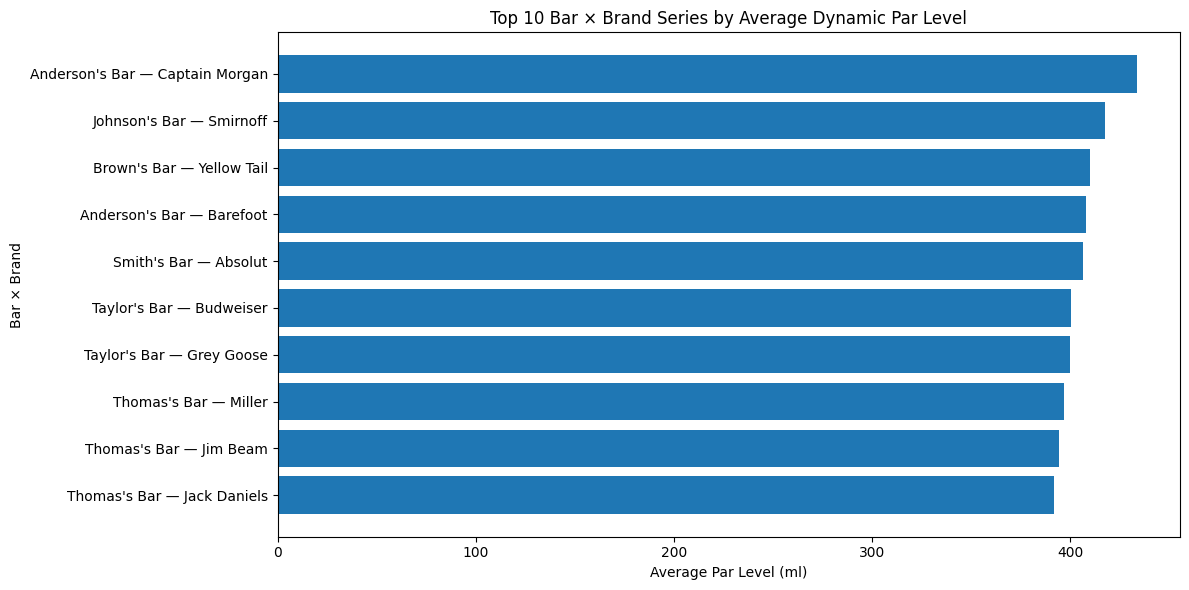

In [68]:
# ============================================================
# STEP 4 — DYNAMIC POLICY VISUALIZATION
# ============================================================

top_series = (
    policy_summary
    .nlargest(10, "Avg_Par_Level")
    .copy()
)

plt.figure(figsize=(12, 6))

plt.barh(
    top_series["Bar Name"] + " — " + top_series["Brand Name"],
    top_series["Avg_Par_Level"]
)

plt.xlabel("Average Par Level (ml)")
plt.ylabel("Bar × Brand")
plt.title("Top 10 Bar × Brand Series by Average Dynamic Par Level")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

Step 4 validation checks

In [69]:
# ============================================================
# STEP 4 — VALIDATION CHECKS
# ============================================================

print("=" * 80)
print("STEP 4 VALIDATION CHECKS")
print("=" * 80)

# 1. Check for missing values
print("\n1. Missing values:")
print(dynamic_policy_df[
    [
        "Forecasted Daily Demand",
        "Daily Demand Std",
        "Lead Time Demand",
        "Safety Stock",
        "Par Level"
    ]
].isna().sum())

# 2. Check for negative values
print("\n2. Negative values:")

numeric_policy_cols = [
    "Forecasted Daily Demand",
    "Daily Demand Std",
    "Lead Time Demand",
    "Safety Stock",
    "Par Level"
]

print(
    (dynamic_policy_df[numeric_policy_cols] < 0).sum()
)

# 3. Verify par-level formula
par_check = np.isclose(
    dynamic_policy_df["Par Level"],
    dynamic_policy_df["Lead Time Demand"]
    + dynamic_policy_df["Safety Stock"]
)

print("\n3. Par-level formula check:")
print(f"All rows valid: {par_check.all()}")

# 4. Verify lead-time demand formula
lead_time_check = np.isclose(
    dynamic_policy_df["Lead Time Demand"],
    dynamic_policy_df["Forecasted Daily Demand"]
    * LEAD_TIME_DAYS
)

print("\n4. Lead-time demand check:")
print(f"All rows valid: {lead_time_check.all()}")

# 5. Verify expected number of observations
expected_rows = 74 * 96

print("\n5. Expected test observations:")
print(f"Expected rows: {expected_rows:,}")
print(f"Actual rows  : {len(dynamic_policy_df):,}")
print(f"Correct      : {len(dynamic_policy_df) == expected_rows}")

# 6. Verify expected number of series
series_count = dynamic_policy_df[
    ["Bar Name", "Brand Name"]
].drop_duplicates().shape[0]

print("\n6. Bar × Brand series:")
print(f"Expected: 96")
print(f"Actual  : {series_count}")
print(f"Correct : {series_count == 96}")

# 7. Final policy range
print("\n7. Policy range:")
print(
    f"Minimum par level: "
    f"{dynamic_policy_df['Par Level'].min():.3f} ml"
)
print(
    f"Maximum par level: "
    f"{dynamic_policy_df['Par Level'].max():.3f} ml"
)

print("\n✅ Step 4 validation completed.")

STEP 4 VALIDATION CHECKS

1. Missing values:
Forecasted Daily Demand    0
Daily Demand Std           0
Lead Time Demand           0
Safety Stock               0
Par Level                  0
dtype: int64

2. Negative values:
Forecasted Daily Demand    0
Daily Demand Std           0
Lead Time Demand           0
Safety Stock               0
Par Level                  0
dtype: int64

3. Par-level formula check:
All rows valid: True

4. Lead-time demand check:
All rows valid: True

5. Expected test observations:
Expected rows: 7,104
Actual rows  : 7,104
Correct      : True

6. Bar × Brand series:
Expected: 96
Actual  : 96
Correct : True

7. Policy range:
Minimum par level: 230.322 ml
Maximum par level: 949.696 ml

✅ Step 4 validation completed.


# Step 5 — Inventory Simulation & Historical Backtest

The dynamic Par Level policy is evaluated through a discrete daily inventory simulation across all 96 Bar × Brand series.

The simulation receives pending orders after the 2-day lead time, fulfills actual demand, records lost volume during stockouts, and places replenishment orders to restore inventory toward the Par Level.


### Simulation engine


In [71]:
# ============================================================
# STEP 5 — INVENTORY SIMULATION ENGINE
# ============================================================

def simulate_inventory(
    policy_df,
    initial_inventory_factor=1.0,
    review_period_days=1
):
    """
    Simulate daily inventory for one Bar × Brand series.

    Inventory policy:
        Target inventory = current day's Par Level

    Ordering rule:
        If projected inventory after today's demand is below
        the current par level, order enough to restore inventory
        to the par level.

    Receiving:
        Orders arrive after LEAD_TIME_DAYS.

    Stockout:
        Any demand that cannot be fulfilled is counted as
        lost volume.
    """

    df = policy_df.sort_values("Date").copy().reset_index(drop=True)

    if df.empty:
        return pd.DataFrame()

    # Initial inventory
    initial_par = df.loc[0, "Par Level"]
    inventory = initial_par * initial_inventory_factor

    pending_orders = {}

    results = []

    for i, row in df.iterrows():

        date = row["Date"]
        demand = max(float(row["Consumed (ml)"]), 0.0)
        par_level = max(float(row["Par Level"]), 0.0)

        # ----------------------------------------------------
        # Receive orders scheduled for today
        # ----------------------------------------------------
        received_today = pending_orders.pop(date, 0.0)

        inventory_before_demand = inventory + received_today

        # ----------------------------------------------------
        # Fulfill demand
        # ----------------------------------------------------
        fulfilled = min(inventory_before_demand, demand)

        lost_volume = max(demand - fulfilled, 0.0)

        ending_inventory = max(
            inventory_before_demand - fulfilled,
            0.0
        )

        stockout = lost_volume > 0

        # ----------------------------------------------------
        # Ordering decision
        # ----------------------------------------------------
        outstanding_orders = sum(pending_orders.values())

        projected_inventory = (
            ending_inventory + outstanding_orders
        )

        order_quantity = max(
            par_level - projected_inventory,
            0.0
        )

        if order_quantity > 0:
            arrival_date = date + pd.Timedelta(days=LEAD_TIME_DAYS)

            if arrival_date not in pending_orders:
                pending_orders[arrival_date] = 0.0

            pending_orders[arrival_date] += order_quantity

        # ----------------------------------------------------
        # Save daily results
        # ----------------------------------------------------
        results.append({
            "Date": date,
            "Bar Name": row["Bar Name"],
            "Brand Name": row["Brand Name"],
            "Demand (ml)": demand,
            "Forecast (ml)": row["Forecasted Daily Demand"],
            "Par Level (ml)": par_level,
            "Beginning Inventory (ml)": inventory,
            "Received (ml)": received_today,
            "Available Inventory (ml)": inventory_before_demand,
            "Fulfilled Demand (ml)": fulfilled,
            "Lost Volume (ml)": lost_volume,
            "Ending Inventory (ml)": ending_inventory,
            "Order Quantity (ml)": order_quantity,
            "Stockout": stockout
        })

        inventory = ending_inventory

    return pd.DataFrame(results)


print("✅ Inventory simulation engine created.")

✅ Inventory simulation engine created.


Run the simulation for all 96 series

In [72]:
# ============================================================
# STEP 5 — RUN SIMULATION FOR ALL 96 BAR × BRAND SERIES
# ============================================================

simulation_results = []

for (bar_name, brand_name), group in dynamic_policy_df.groupby(
    ["Bar Name", "Brand Name"]
):

    result = simulate_inventory(
        group,
        initial_inventory_factor=1.0,
        review_period_days=1
    )

    simulation_results.append(result)

simulation_df = (
    pd.concat(simulation_results, ignore_index=True)
    .sort_values(["Date", "Bar Name", "Brand Name"])
    .reset_index(drop=True)
)

print("=" * 80)
print("INVENTORY SIMULATION")
print("=" * 80)

print(f"Rows              : {len(simulation_df):,}")
print(
    f"Bar × Brand series : "
    f"{simulation_df[['Bar Name', 'Brand Name']].drop_duplicates().shape[0]}"
)
print(
    f"Date range         : "
    f"{simulation_df['Date'].min().date()} -> "
    f"{simulation_df['Date'].max().date()}"
)

print("\n✅ Simulation completed for all 96 series.")

display(simulation_df.head(15))

INVENTORY SIMULATION
Rows              : 7,104
Bar × Brand series : 96
Date range         : 2023-10-20 -> 2024-01-01

✅ Simulation completed for all 96 series.


,Date,Bar Name,Brand Name,Demand (ml),Forecast (ml),Par Level (ml),Beginning Inventory (ml),Received (ml),Available Inventory (ml),Fulfilled Demand (ml),Lost Volume (ml),Ending Inventory (ml),Order Quantity (ml),Stockout
0,2023-10-20,Anderson's Bar,Absolut,0.00,0.00000,230.322034,230.322034,0.0,230.322034,0.00,0.0,230.322034,0.00,False
1,2023-10-20,Anderson's Bar,Bacardi,0.00,148.49375,672.054514,672.054514,0.0,672.054514,0.00,0.0,672.054514,0.00,False
2,2023-10-20,Anderson's Bar,Barefoot,587.94,129.54500,641.525690,641.525690,0.0,641.525690,587.94,0.0,53.585690,587.94,False
3,2023-10-20,Anderson's Bar,Budweiser,0.00,52.52625,361.657734,361.657734,0.0,361.657734,0.00,0.0,361.657734,0.00,False
4,2023-10-20,Anderson's Bar,Captain Morgan,221.90,0.00000,416.949300,416.949300,0.0,416.949300,221.90,0.0,195.049300,221.90,False
5,2023-10-20,Anderson's Bar,Coors,0.00,44.89375,433.191019,433.191019,0.0,433.191019,0.00,0.0,433.191019,0.00,False
6,2023-10-20,Anderson's Bar,Grey Goose,0.00,0.00000,366.735388,366.735388,0.0,366.735388,0.00,0.0,366.735388,0.00,False
7,2023-10-20,Anderson's Bar,Heineken,0.00,65.35375,449.784182,449.784182,0.0,449.784182,0.00,0.0,449.784182,0.00,False
8,2023-10-20,Anderson's Bar,Jack Daniels,0.00,86.48375,483.653946,483.653946,0.0,483.653946,0.00,0.0,483.653946,0.00,False
9,2023-10-20,Anderson's Bar,Jameson,0.00,141.31000,648.049805,648.049805,0.0,648.049805,0.00,0.0,648.049805,0.00,False


Overall business KPIs

In [73]:
# ============================================================
# STEP 5 — OVERALL BUSINESS KPIs
# ============================================================

total_demand = simulation_df["Demand (ml)"].sum()
total_fulfilled = simulation_df["Fulfilled Demand (ml)"].sum()
total_lost = simulation_df["Lost Volume (ml)"].sum()

service_level = (
    total_fulfilled / total_demand * 100
    if total_demand > 0 else 0
)

# Stockout series-days
stockout_series_days = int(
    simulation_df["Stockout"].sum()
)

# Unique calendar days with at least one stockout
stockout_calendar_days = simulation_df.loc[
    simulation_df["Stockout"], "Date"
].nunique()

# Total inventory held across all 96 series for each date
daily_total_inventory = (
    simulation_df
    .groupby("Date")["Ending Inventory (ml)"]
    .sum()
)

average_total_inventory = daily_total_inventory.mean()

total_orders = int(
    (simulation_df["Order Quantity (ml)"] > 0).sum()
)

total_ordered = simulation_df[
    "Order Quantity (ml)"
].sum()

inventory_turnover = (
    total_demand / average_total_inventory
    if average_total_inventory > 0 else np.nan
)

print("=" * 80)
print("STEP 5 — OVERALL BUSINESS KPIs")
print("=" * 80)

print(f"Total demand                 : {total_demand:,.2f} ml")
print(f"Fulfilled demand             : {total_fulfilled:,.2f} ml")
print(f"Lost volume                  : {total_lost:,.2f} ml")
print(f"Service level                : {service_level:.2f}%")
print(f"Stockout series-days         : {stockout_series_days:,}")
print(f"Stockout calendar days       : {stockout_calendar_days:,}")
print(f"Average total inventory      : {average_total_inventory:,.2f} ml")
print(f"Total order events           : {total_orders:,}")
print(f"Total ordered volume         : {total_ordered:,.2f} ml")
print(f"Inventory turnover           : {inventory_turnover:.2f}")

print("\n✅ Corrected overall inventory KPIs calculated.")

STEP 5 — OVERALL BUSINESS KPIs
Total demand                 : 395,762.81 ml
Fulfilled demand             : 287,291.29 ml
Lost volume                  : 108,471.52 ml
Service level                : 72.59%
Stockout series-days         : 586
Stockout calendar days       : 72
Average total inventory      : 27,965.57 ml
Total order events           : 1,163
Total ordered volume         : 276,885.94 ml
Inventory turnover           : 14.15

✅ Corrected overall inventory KPIs calculated.


Find the series with the largest stockout exposure

In [74]:
# ============================================================
# STEP 5 — LARGEST STOCKOUT EXPOSURE
# ============================================================

stockout_exposure = (
    simulation_df
    .groupby(["Bar Name", "Brand Name"], as_index=False)
    .agg(
        Stockout_Series_Days=("Stockout", "sum"),
        Lost_Volume_ml=("Lost Volume (ml)", "sum"),
        Total_Demand_ml=("Demand (ml)", "sum"),
        Fulfilled_Demand_ml=("Fulfilled Demand (ml)", "sum")
    )
)

stockout_exposure["Service_Level_%"] = np.where(
    stockout_exposure["Total_Demand_ml"] > 0,
    stockout_exposure["Fulfilled_Demand_ml"]
    / stockout_exposure["Total_Demand_ml"] * 100,
    0
)

stockout_exposure = (
    stockout_exposure
    .sort_values(
        ["Lost_Volume_ml", "Stockout_Series_Days"],
        ascending=False
    )
    .reset_index(drop=True)
)

print("=" * 80)
print("LARGEST STOCKOUT EXPOSURE")
print("=" * 80)

display(stockout_exposure.head(15))

print("\n✅ Stockout exposure analysis completed.")

LARGEST STOCKOUT EXPOSURE


,Bar Name,Brand Name,Stockout_Series_Days,Lost_Volume_ml,Total_Demand_ml,Fulfilled_Demand_ml,Service_Level_%
0,Thomas's Bar,Yellow Tail,16,2970.036677,7065.50,4095.463323,57.964239
1,Taylor's Bar,Jim Beam,12,2952.423225,6520.79,3568.366775,54.722921
2,Brown's Bar,Coors,6,2940.541727,4970.35,2029.808273,40.838337
3,Taylor's Bar,Sutter Home,9,2716.995329,5130.61,2413.614671,47.043425
4,Johnson's Bar,Jim Beam,11,2403.787973,5240.77,2836.982027,54.132924
5,Taylor's Bar,Smirnoff,12,2381.283232,6983.46,4602.176768,65.901097
6,Brown's Bar,Grey Goose,11,2228.833620,6403.66,4174.826380,65.194379
7,Taylor's Bar,Jameson,9,2187.103669,5029.53,2842.426331,56.514750
8,Brown's Bar,Jameson,10,2107.018091,6536.21,4429.191909,67.763917
9,Brown's Bar,Malibu,11,2071.740891,5517.11,3445.369109,62.448802



✅ Stockout exposure analysis completed.


Plot inventory behavior

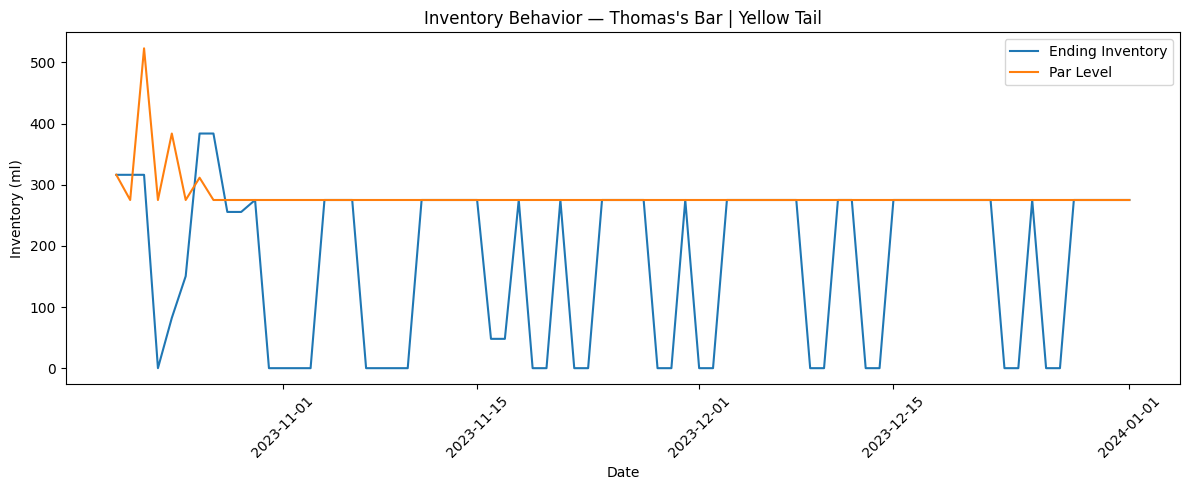

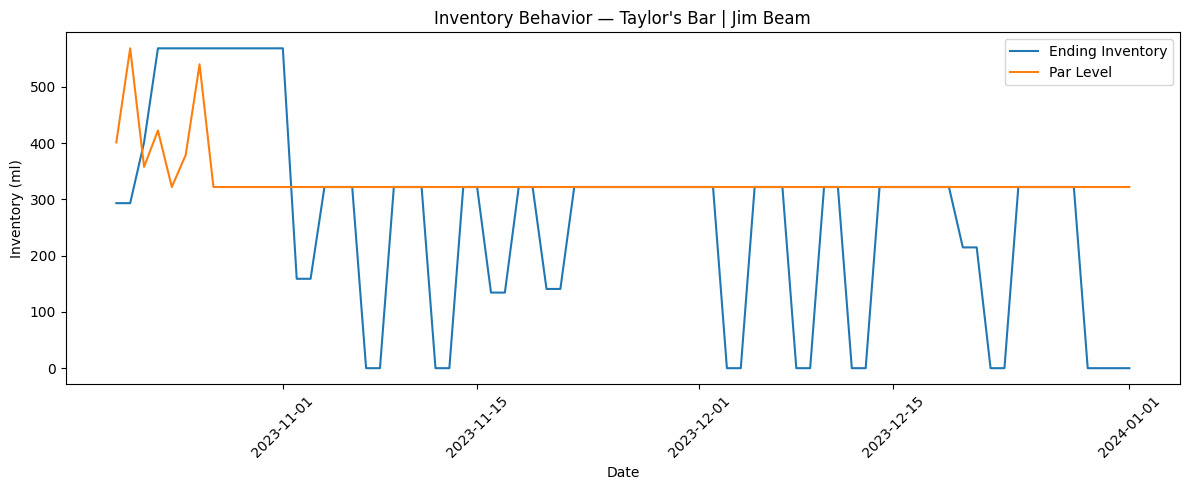

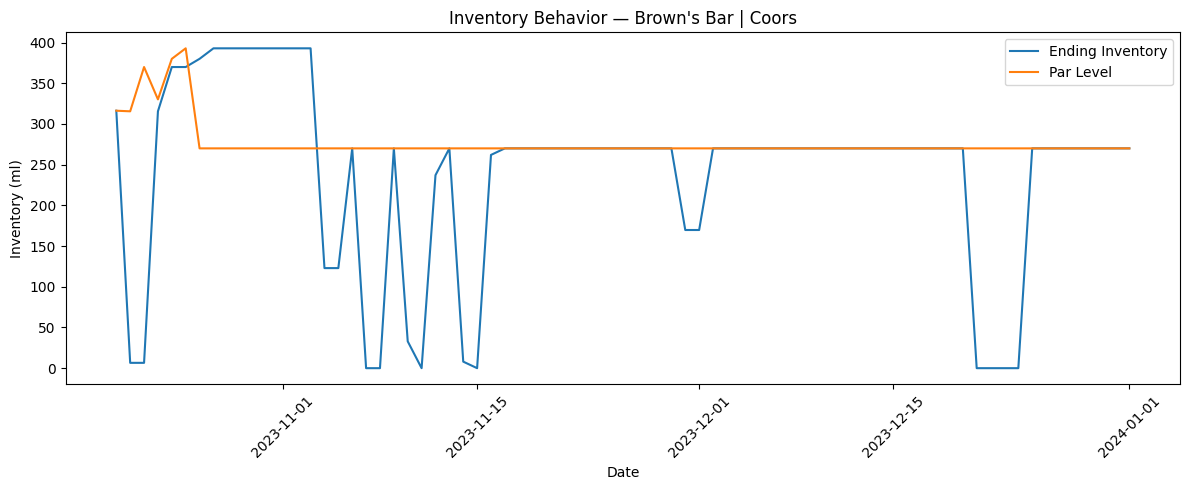

✅ Inventory behavior visualization completed.


In [75]:
# ============================================================
# STEP 5 — INVENTORY BEHAVIOR VISUALIZATION
# ============================================================

# Select the 3 series with the highest lost volume
top_3_series = (
    stockout_exposure
    .nlargest(3, "Lost_Volume_ml")
    [["Bar Name", "Brand Name"]]
)

for _, series in top_3_series.iterrows():

    bar = series["Bar Name"]
    brand = series["Brand Name"]

    plot_df = simulation_df[
        (simulation_df["Bar Name"] == bar) &
        (simulation_df["Brand Name"] == brand)
    ].sort_values("Date")

    plt.figure(figsize=(12, 5))

    plt.plot(
        plot_df["Date"],
        plot_df["Ending Inventory (ml)"],
        label="Ending Inventory"
    )

    plt.plot(
        plot_df["Date"],
        plot_df["Par Level (ml)"],
        label="Par Level"
    )

    plt.xlabel("Date")
    plt.ylabel("Inventory (ml)")
    plt.title(f"Inventory Behavior — {bar} | {brand}")
    plt.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

print("✅ Inventory behavior visualization completed.")

Final Step 5 validation

In [76]:
# ============================================================
# STEP 5 — FINAL VALIDATION
# ============================================================

print("=" * 80)
print("FINAL STEP 5 VALIDATION")
print("=" * 80)

# 1. Check for missing values in simulation output
required_columns = [
    "Date",
    "Bar Name",
    "Brand Name",
    "Demand (ml)",
    "Forecast (ml)",
    "Par Level (ml)",
    "Beginning Inventory (ml)",
    "Received (ml)",
    "Available Inventory (ml)",
    "Fulfilled Demand (ml)",
    "Lost Volume (ml)",
    "Ending Inventory (ml)",
    "Order Quantity (ml)",
    "Stockout"
]

missing_check = simulation_df[required_columns].isna().sum()

print("\n1. Missing values:")
print(missing_check)

# 2. Check for negative inventory
negative_inventory = (
    simulation_df[
        [
            "Beginning Inventory (ml)",
            "Available Inventory (ml)",
            "Fulfilled Demand (ml)",
            "Lost Volume (ml)",
            "Ending Inventory (ml)",
            "Order Quantity (ml)"
        ]
    ] < 0
).sum()

print("\n2. Negative inventory / flow values:")
print(negative_inventory)

# 3. Demand conservation:
# Demand = Fulfilled Demand + Lost Volume
demand_check = np.isclose(
    simulation_df["Demand (ml)"],
    simulation_df["Fulfilled Demand (ml)"]
    + simulation_df["Lost Volume (ml)"]
)

print("\n3. Demand conservation check:")
print(f"All rows valid: {demand_check.all()}")

# 4. Inventory flow check
inventory_flow_check = np.isclose(
    simulation_df["Available Inventory (ml)"],
    simulation_df["Beginning Inventory (ml)"]
    + simulation_df["Received (ml)"]
)

print("\n4. Inventory availability check:")
print(f"All rows valid: {inventory_flow_check.all()}")

# 5. Fulfillment cannot exceed available inventory
fulfillment_check = (
    simulation_df["Fulfilled Demand (ml)"]
    <= simulation_df["Available Inventory (ml)"] + 1e-9
)

print("\n5. Fulfillment constraint check:")
print(f"All rows valid: {fulfillment_check.all()}")

# 6. Expected observations
expected_rows = 74 * 96

print("\n6. Expected simulation rows:")
print(f"Expected: {expected_rows:,}")
print(f"Actual  : {len(simulation_df):,}")
print(f"Correct : {len(simulation_df) == expected_rows}")

# 7. Expected series count
series_count = simulation_df[
    ["Bar Name", "Brand Name"]
].drop_duplicates().shape[0]

print("\n7. Bar × Brand series:")
print(f"Expected: 96")
print(f"Actual  : {series_count}")
print(f"Correct : {series_count == 96}")

# 8. Final test date range
print("\n8. Final test date range:")
print(f"Start: {simulation_df['Date'].min().date()}")
print(f"End  : {simulation_df['Date'].max().date()}")

# 9. Final validation result
all_valid = (
    missing_check.sum() == 0
    and negative_inventory.sum() == 0
    and demand_check.all()
    and inventory_flow_check.all()
    and fulfillment_check.all()
    and len(simulation_df) == expected_rows
    and series_count == 96
)

print("\n" + "=" * 80)
print(f"FINAL VALIDATION PASSED: {all_valid}")
print("=" * 80)

if all_valid:
    print("✅ Step 5 simulation is internally consistent.")
else:
    print("❌ Step 5 validation found an issue that must be investigated.")

FINAL STEP 5 VALIDATION

1. Missing values:
Date                        0
Bar Name                    0
Brand Name                  0
Demand (ml)                 0
Forecast (ml)               0
Par Level (ml)              0
Beginning Inventory (ml)    0
Received (ml)               0
Available Inventory (ml)    0
Fulfilled Demand (ml)       0
Lost Volume (ml)            0
Ending Inventory (ml)       0
Order Quantity (ml)         0
Stockout                    0
dtype: int64

2. Negative inventory / flow values:
Beginning Inventory (ml)    0
Available Inventory (ml)    0
Fulfilled Demand (ml)       0
Lost Volume (ml)            0
Ending Inventory (ml)       0
Order Quantity (ml)         0
dtype: int64

3. Demand conservation check:
All rows valid: True

4. Inventory availability check:
All rows valid: True

5. Fulfillment constraint check:
All rows valid: True

6. Expected simulation rows:
Expected: 7,104
Actual  : 7,104
Correct : True

7. Bar × Brand series:
Expected: 96
Actual  : 96
Cor

# Step 6 — Final Results & Business Summary


In [ ]:
# ============================================================
# STEP 6 — FINAL RESULTS & BUSINESS SUMMARY
# ============================================================

print("=" * 80)
print("FINAL PROJECT RESULTS")
print("=" * 80)

print("\nFORECASTING MODEL")
print("-----------------")
print(f"Selected model        : {FINAL_MODEL_NAME}")
print(f"Final Test MAE        : {final_mae:.3f} ml")
print(f"Final Test WAPE       : {final_wape:.3f}%")

print("\nINVENTORY POLICY")
print("----------------")
print(f"Lead time             : {LEAD_TIME_DAYS} days")
print("Service level         : 95%")
print(f"Average par level     : {dynamic_policy_df['Par Level'].mean():.2f} ml")
print(f"Maximum par level     : {dynamic_policy_df['Par Level'].max():.2f} ml")

print("\nINVENTORY SIMULATION")
print("--------------------")
print(f"Total demand          : {total_demand:,.2f} ml")
print(f"Fulfilled demand      : {total_fulfilled:,.2f} ml")
print(f"Lost volume           : {total_lost:,.2f} ml")
print(f"Service level         : {service_level:.2f}%")
print(f"Stockout series-days  : {stockout_series_days:,}")
print(f"Stockout calendar days: {stockout_calendar_days:,}")
print(f"Average inventory     : {average_total_inventory:,.2f} ml")
print(f"Total order events    : {total_orders:,}")
print(f"Total ordered volume  : {total_ordered:,.2f} ml")
print(f"Inventory turnover    : {inventory_turnover:.2f}")

print("\nDATA COVERAGE")
print("-------------")
print("Bar × Brand series    : 96")
print("Final test period     : 2023-10-20 -> 2024-01-01")
print("Final test observations: 7,104")

print("\n✅ Final results consolidated.")
